# Standard Maxx Experiment Template


## Notes
**Overview:** This experiment is designt to test whether flies in which activation of R2/R4 neurons exhibit positive or negative valence.  
**Rationale:** We found that activation of R2 alone neurons was aversive.  Both R2 and R2/R4 activation increases lifespan.   
**Date of Experiment:** 11/12/2024   
**Genotypes:** SS02769-Gal4xWCS; SS02769-Gal4xChrimson   
**Sex:** Females   
**Light Paradigm:** 10min aclimation period with no lights; 60 min 5sec on/5 sec off; 10 min cool down with no lights. 14.4V.   
**Design:** Alternating Control,Chrimson starting with T_0 (top left lane) and alternating throughout.  Details in the _Notes.txt_ file.   
**Misc:** This is the second of two runs on this day.

## Configuration
Configuration was standard. No new or untested code.

In [1]:
#%autoreload 1
import warnings
from Arena import *
import Tracker
import TwoChoiceTracker
from ExperimentalDesign import *
from Parameters import *

# Suppress all warnings
warnings.filterwarnings('ignore')

## Parameters
Just a standard arena max, accepting the default values and a Two-Choice Tracker.

In [2]:
p=Parameters()
p.set_arena_max_values(TrackingType.TWOCHOICETRACKER)
p.print()

tracking_type: TrackingType.TWOCHOICETRACKER
fps: 0
mm_per_pixel: 0.145
speed_window_seconds: 1
micromove_speed_mm_sec: [0.2, 2]
walking_speed_mm_sec: 2
sleep_threshold_min: 5


## Read in the data

Next we will read in the data to an Arena object. The format is`Arena(ExperimentName, parameters, data_path="./")`. This will automatically calculate all relevant metrics for the tracking type in question.  

The name of the experiment and predefined parameters object are required, but _data_path_ is optional (if no data directory is specified, it defaults to the current working directory).

The following files must be present in the defined data directory :
* The DTrack experiment file, which is an excel sheet with the name '_ExperimentName.xlsx_'.
* The DTrack data files themselves, which are named '_ExperimentName_Data_1.csv_', '_ExperimentName_Data_2.csv_', etc.
* An experiment file (most of the time, definitely for a TwoChoiceTracker), which is named '_ExperimentName_Design.txt_'.

In [3]:
arena = Arena.Arena('MaxIRSetup',p,data_path='./Data/Run2/')

## Summary
Get the summary results for all trackers, including treatments, etc.   
This will copy the results to the clipboard and save the data in a file called '_ExperimentName_Summary.csv_'.   
The semicolon at the end of the command will suppress the output to this notebook.  Remove it if you want to see the results dataframe.

In [4]:
arena.summarize(copy_to_clipboard=True,write_to_csvfile=True);

Or you can also create a faceted summary if you want to separate the different phases of the experiment.   
The file name will be '_ExperimentName_Summary_Facet.csv_'.

In [5]:
arena.summarize_facet(cutoffs=(10,70),copy_to_clipboard=True,write_to_csvfile=True);

## Plotting
There are lots of cool plotting funtions.  Some are shown below.

**Facet plots:** First of PI, then Percentage, then Total Distance (in mm/min).   
Cutoffs separate the acclimaton phase from the experiment phase from the cool down phase.

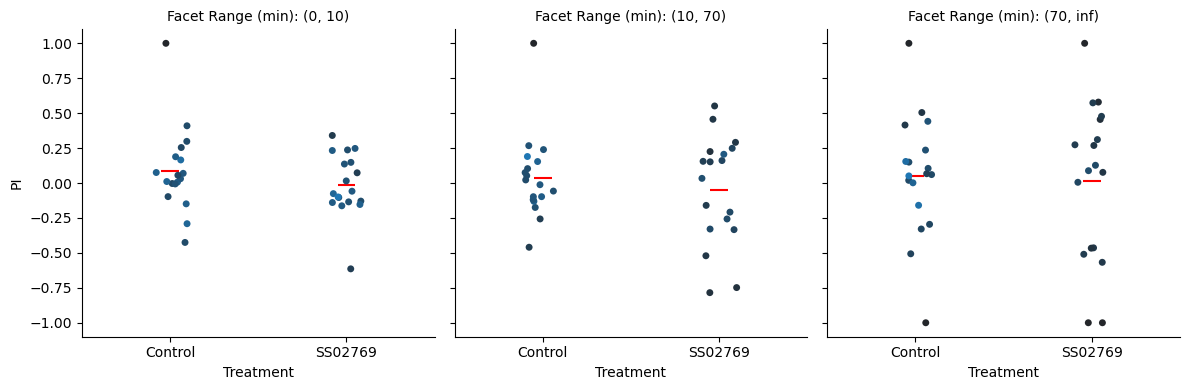

In [6]:
arena.plot_pi_facet(cutoffs=(10,70))

In [7]:
arena.run_pairwise_comparisons_facet(metric="FinalPI",cutoffs=(10,70))

Column = FinalPI, Facet Range = (0.00,10.00)
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper reject
----------------------------------------------------
Control SS02769  -0.1019 0.2578 -0.2817 0.078  False
----------------------------------------------------


Column = FinalPI, Facet Range = (10.00,70.00)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
Control SS02769  -0.0866 0.4612 -0.3226 0.1495  False
-----------------------------------------------------


Column = FinalPI, Facet Range = (70.00,inf)
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj  lower  upper  reject
----------------------------------------------------
Control SS02769  -0.0381 0.8212 -0.378 0.3018  False
----------------------------------------------------




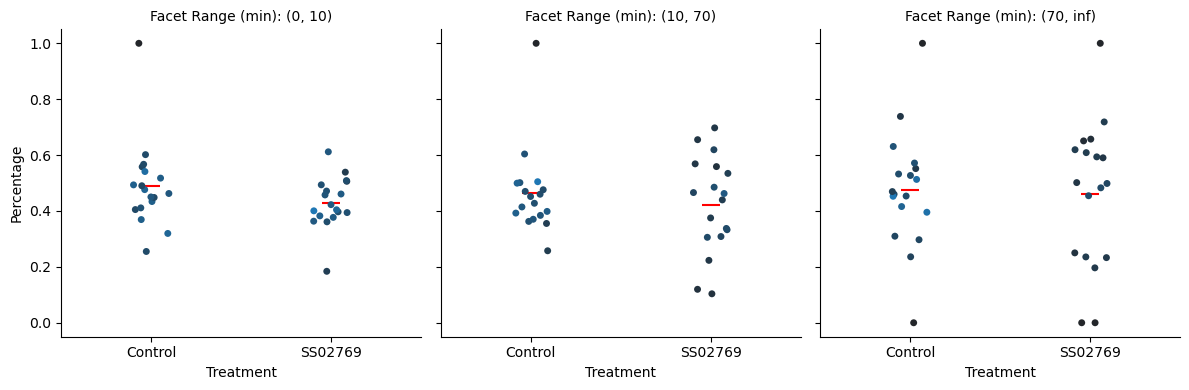

In [8]:
arena.plot_percentage_facet(cutoffs=(10,70))

In [9]:
arena.run_pairwise_comparisons_facet(metric="FinalPercentage",cutoffs=(10,70))

Column = FinalPercentage, Facet Range = (0.00,10.00)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
Control SS02769  -0.0591 0.1717 -0.1452 0.0269  False
-----------------------------------------------------


Column = FinalPercentage, Facet Range = (10.00,70.00)
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj  lower  upper  reject
----------------------------------------------------
Control SS02769  -0.0409 0.458 -0.1518 0.0699  False
----------------------------------------------------


Column = FinalPercentage, Facet Range = (70.00,inf)
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj  lower  upper  reject
----------------------------------------------------
Control SS02769  -0.0146 0.854 -0.1749 0.1456  False
----------------------------------------------------




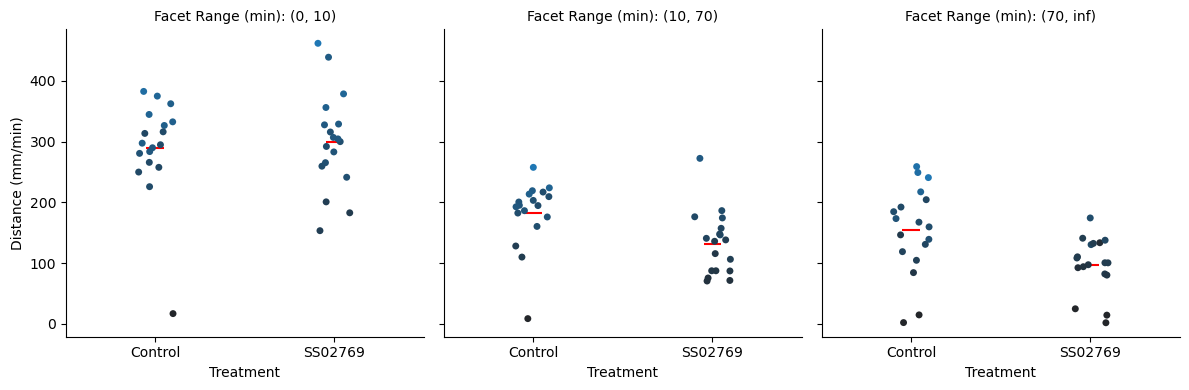

In [10]:
arena.plot_totaldistance_facet(cutoffs=(10,70))

In [11]:
arena.run_pairwise_comparisons_facet(metric="TotalDistance",cutoffs=(10,70))

Column = TotalDistance, Facet Range = (0.00,10.00)
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2 meandiff p-adj    lower    upper   reject
---------------------------------------------------------
Control SS02769 107.5442 0.6943 -443.8257 658.9141  False
---------------------------------------------------------


Column = TotalDistance, Facet Range = (10.00,70.00)
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1  group2  meandiff p-adj    lower      upper   reject
------------------------------------------------------------
Control SS02769 -3007.507 0.0081 -5179.5864 -835.4275   True
------------------------------------------------------------


Column = TotalDistance, Facet Range = (70.00,inf)
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1  group2  meandiff p-adj    lower     upper   reject
-----------------------------------------------------------
Control SS02769 -574.3835 0.0074 -984.2864 -164.4807   True
--------

**Tracker plots:** These show, for each tracker individually, the progression of PI and Percentage showing cumulative values and time-dependent values

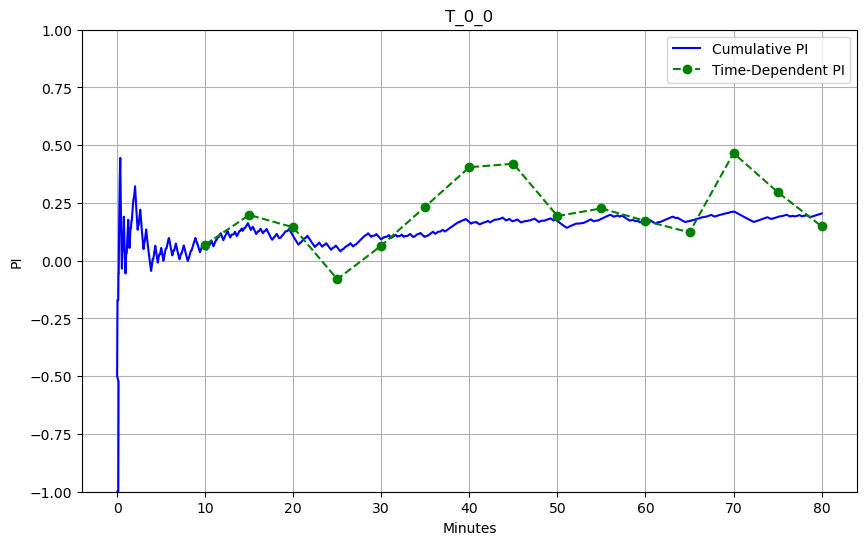

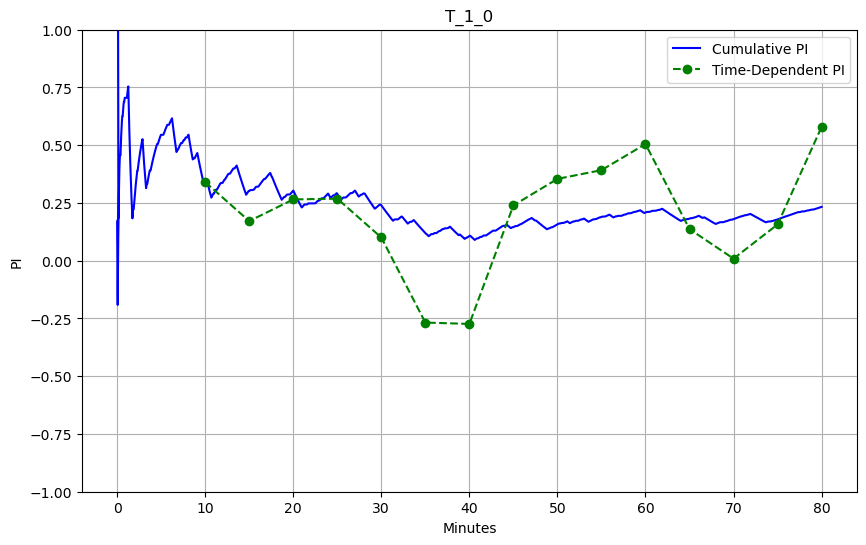

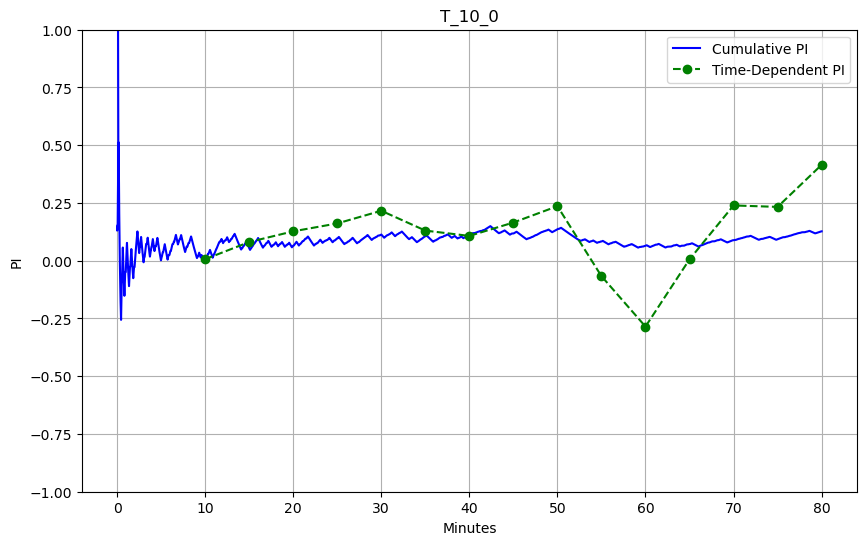

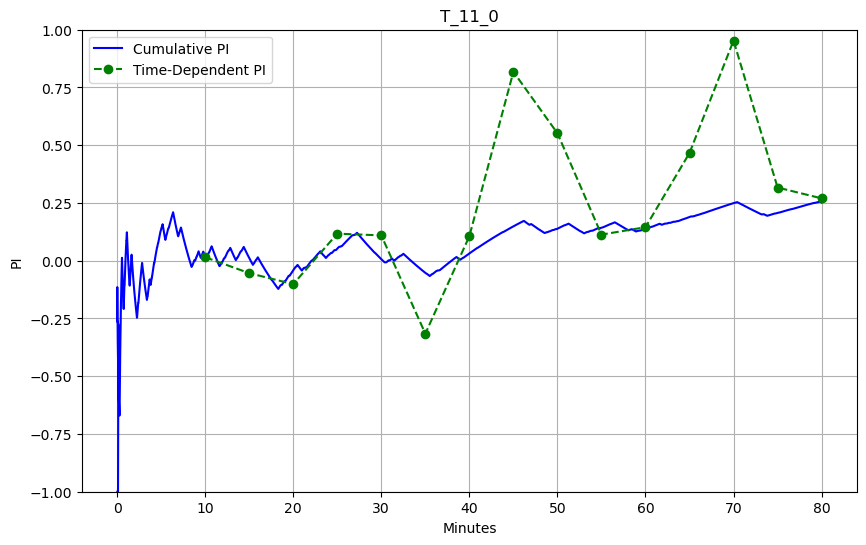

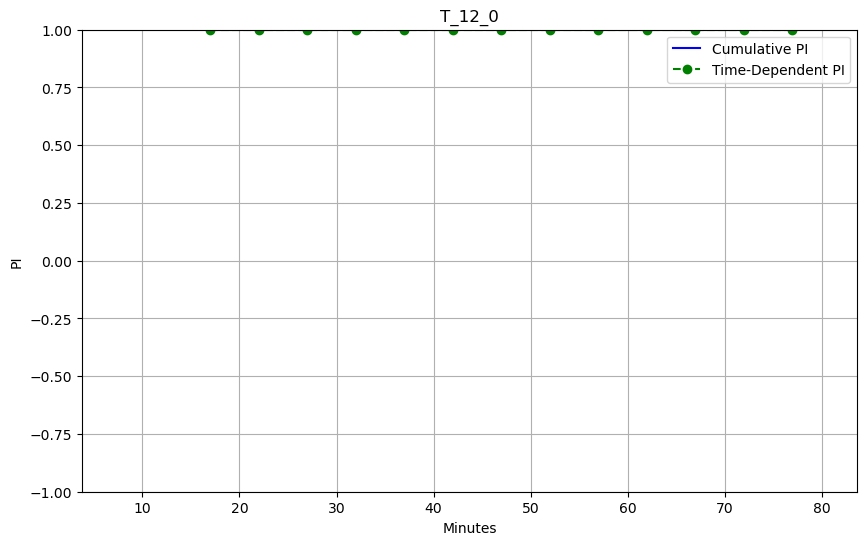

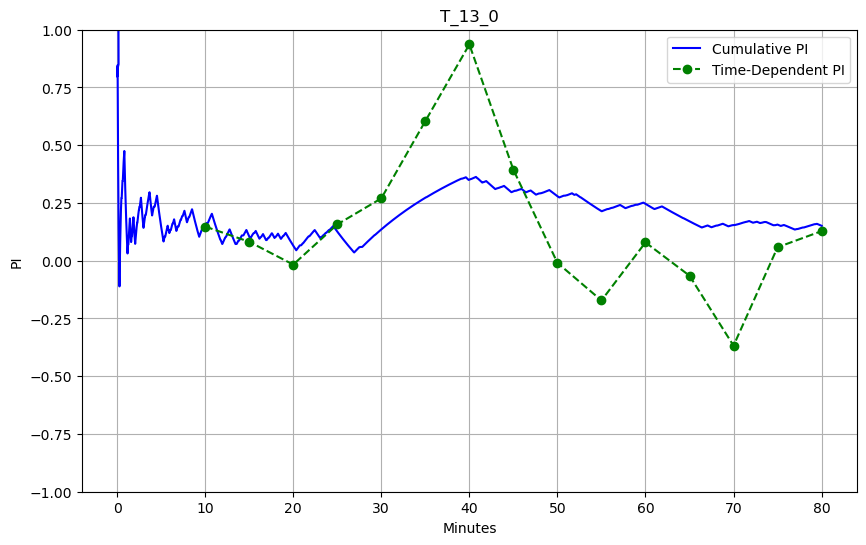

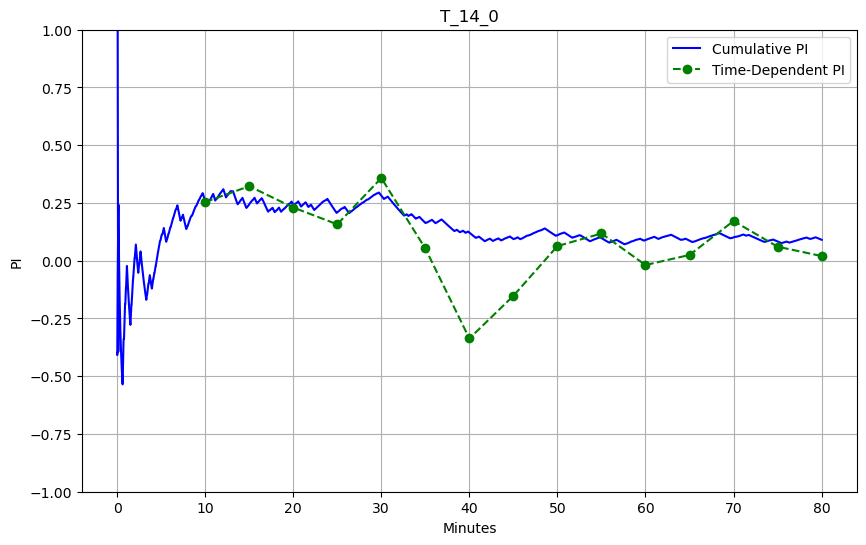

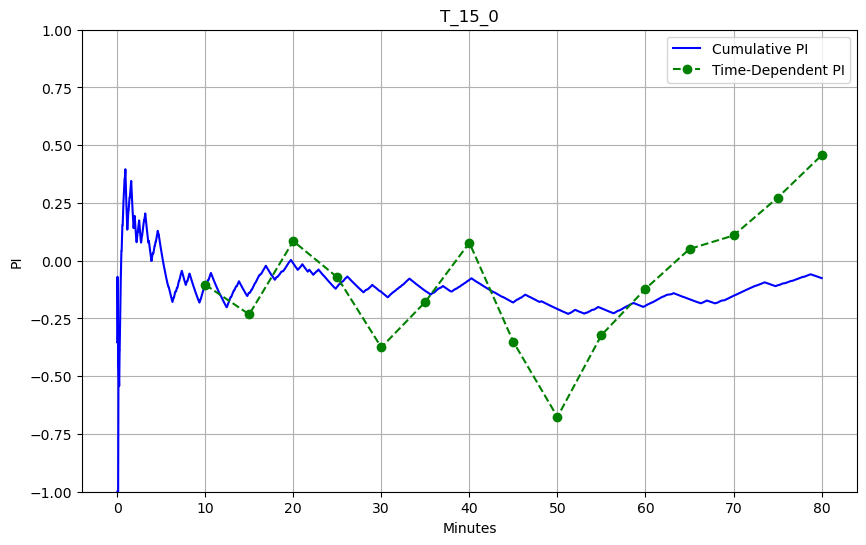

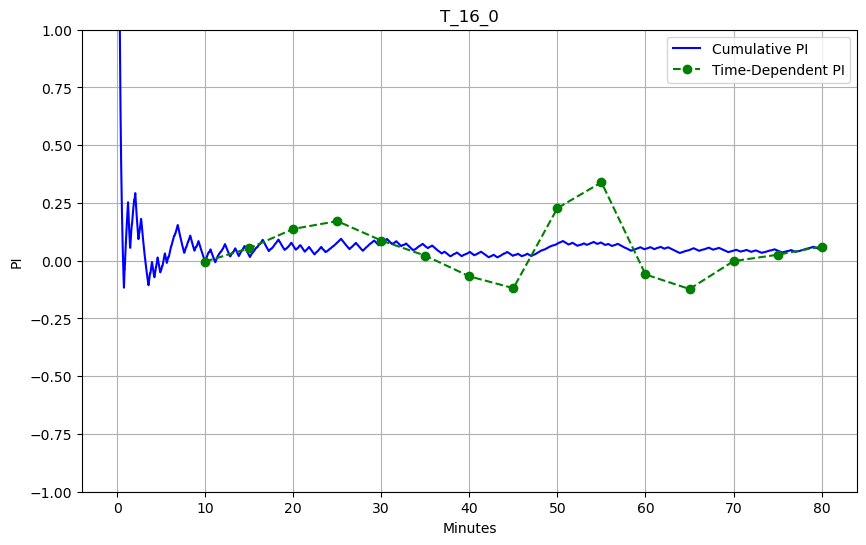

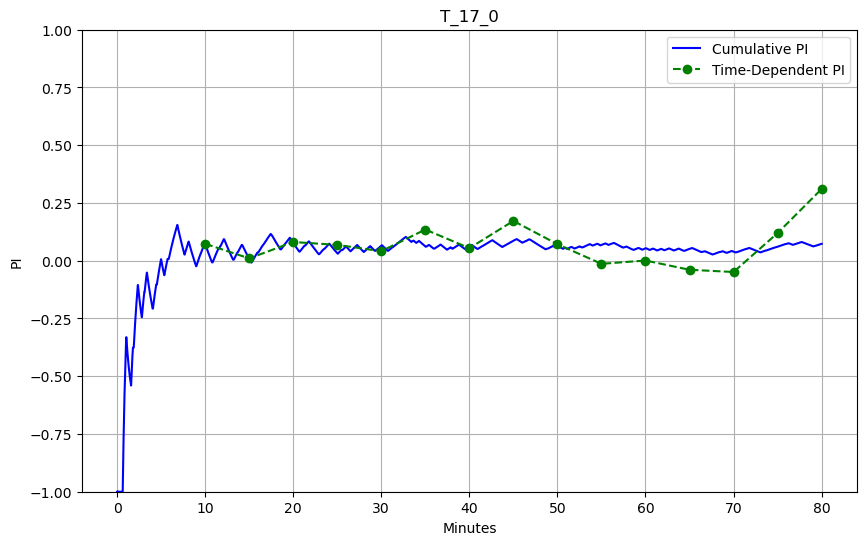

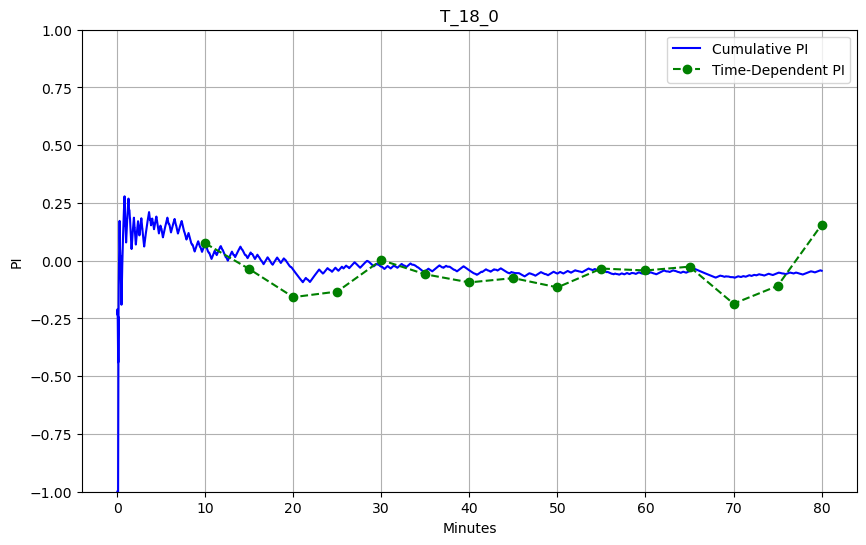

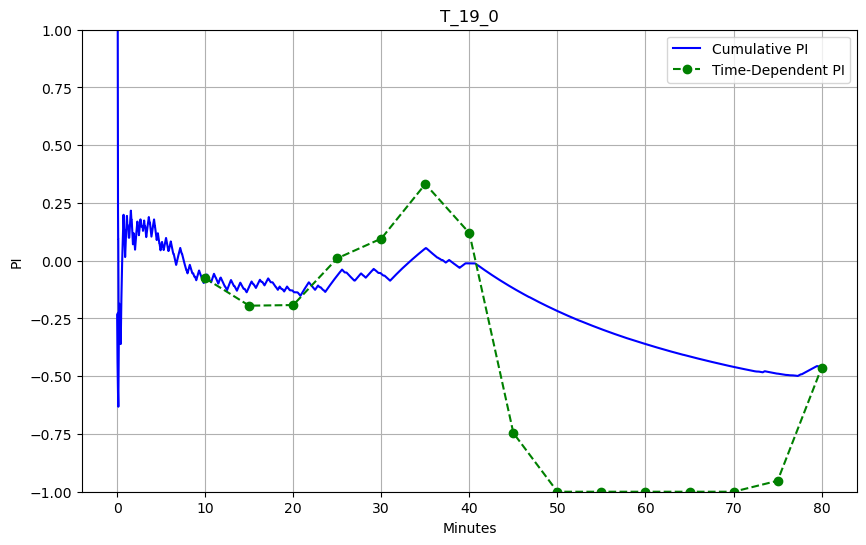

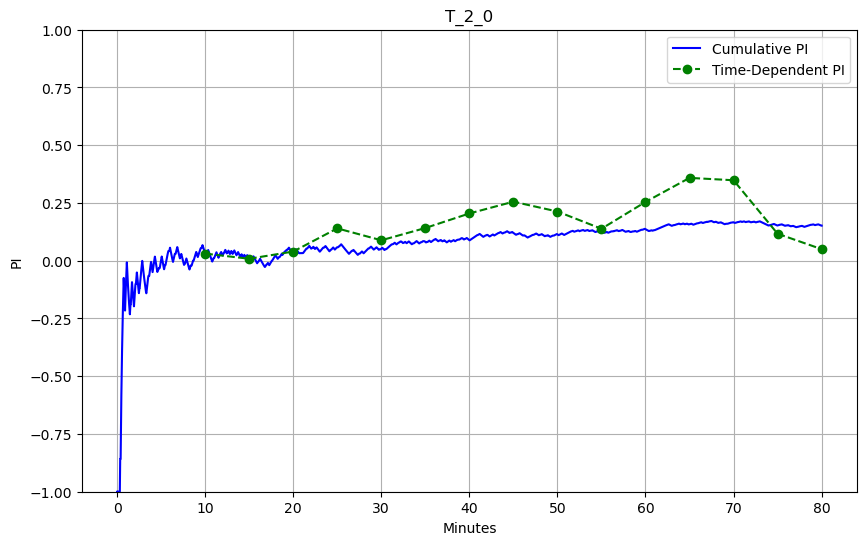

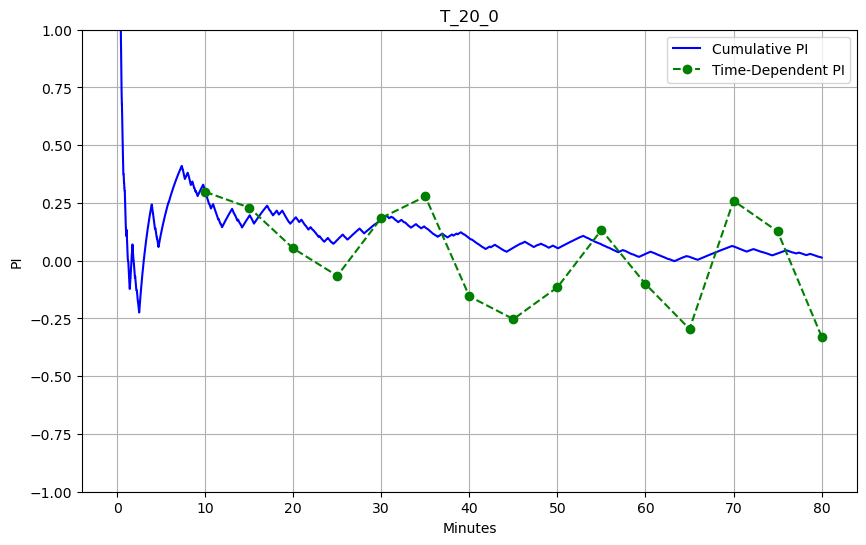

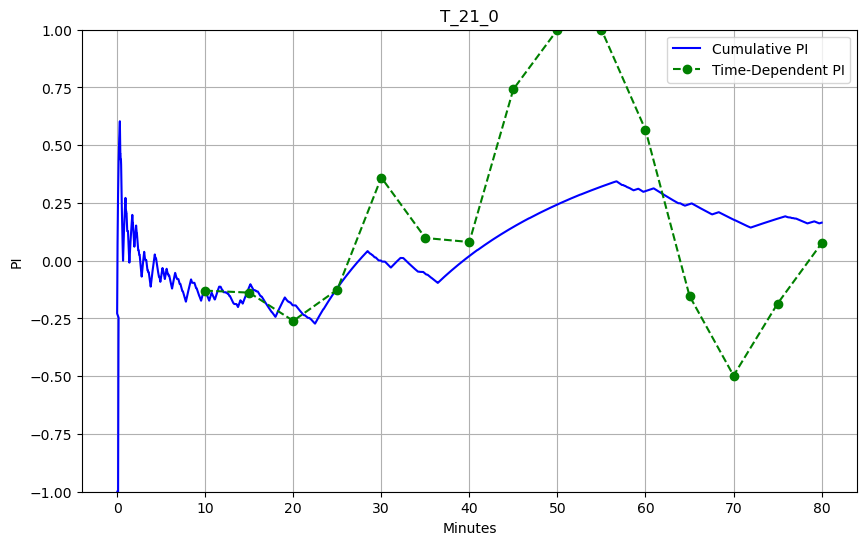

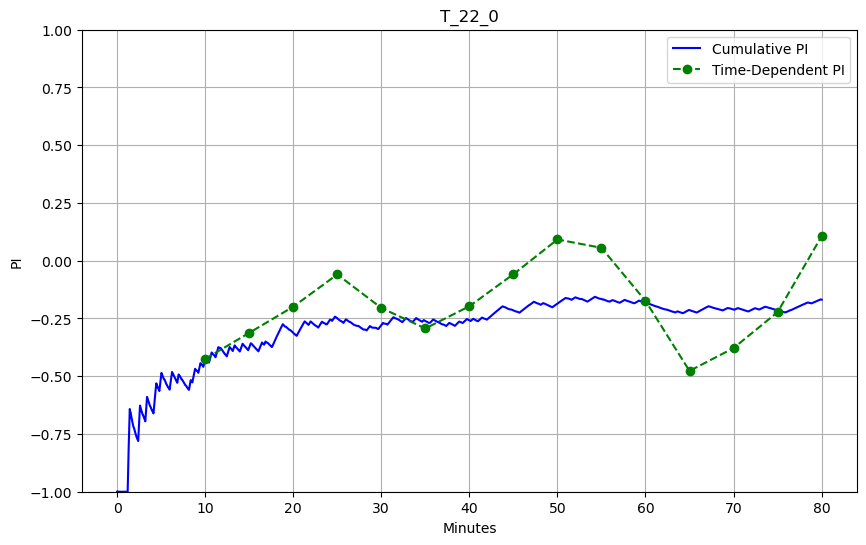

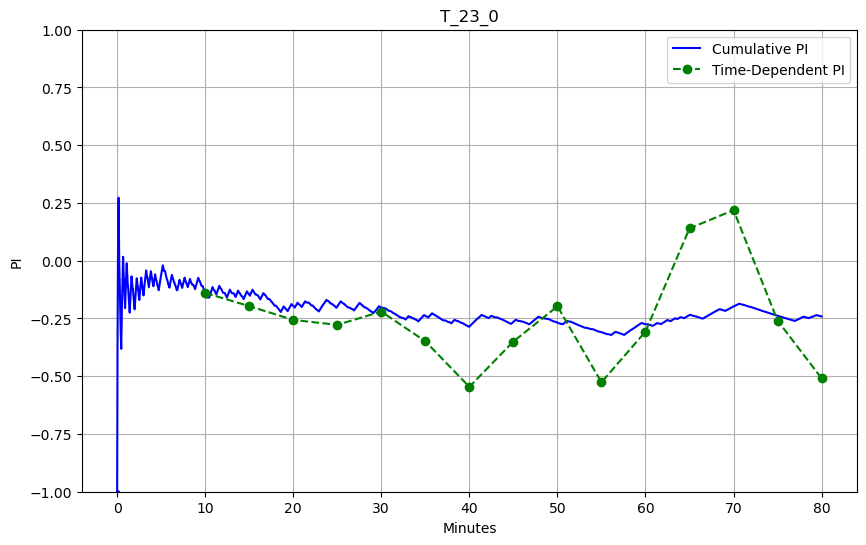

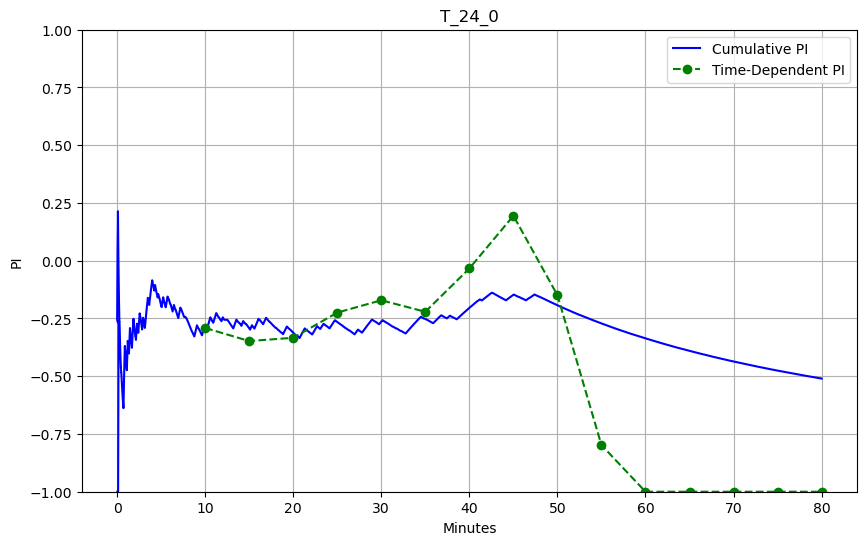

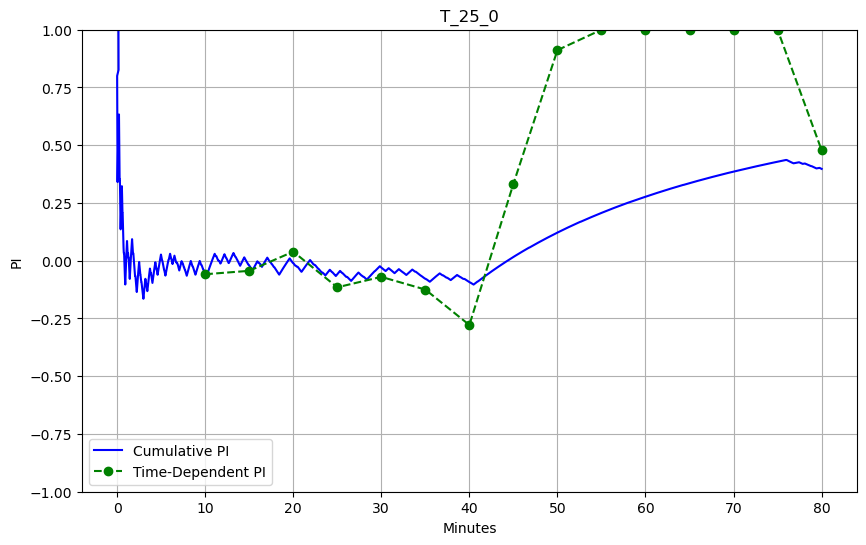

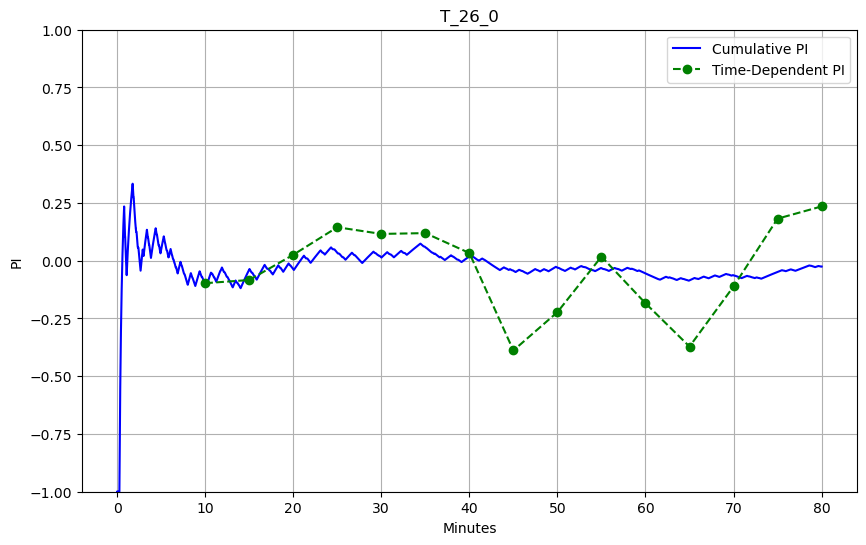

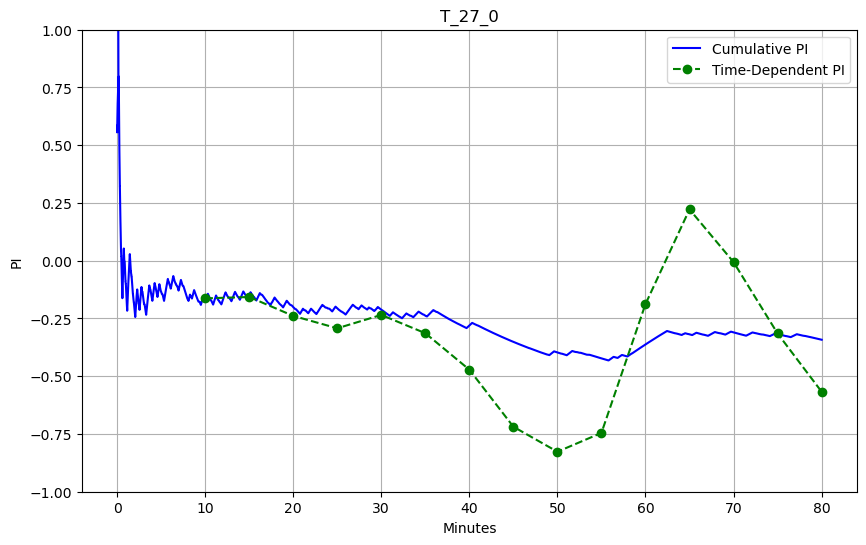

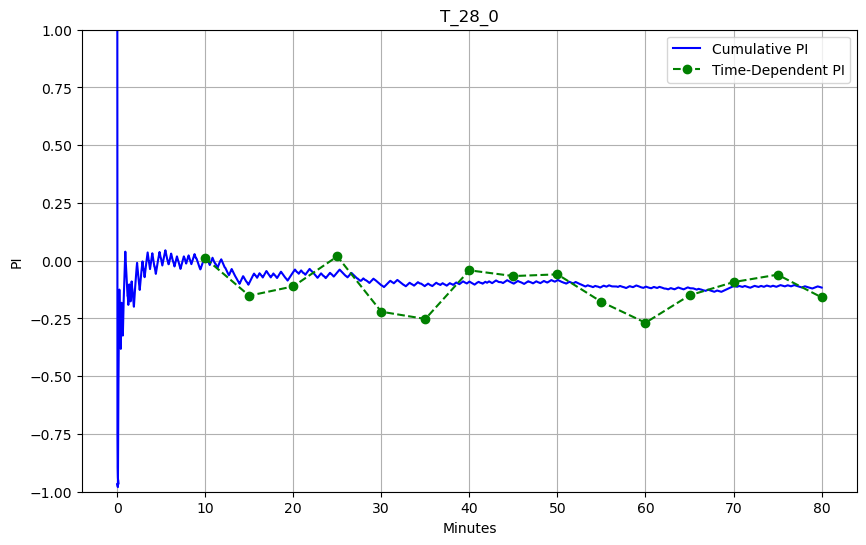

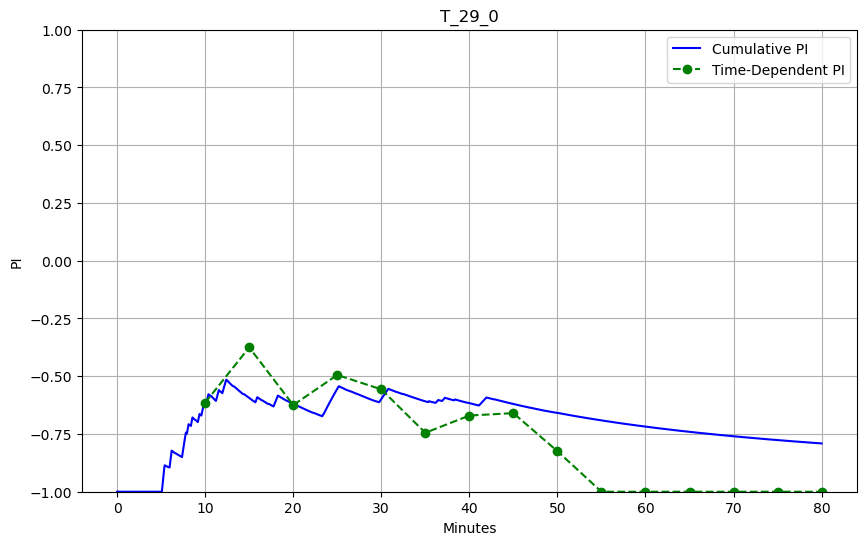

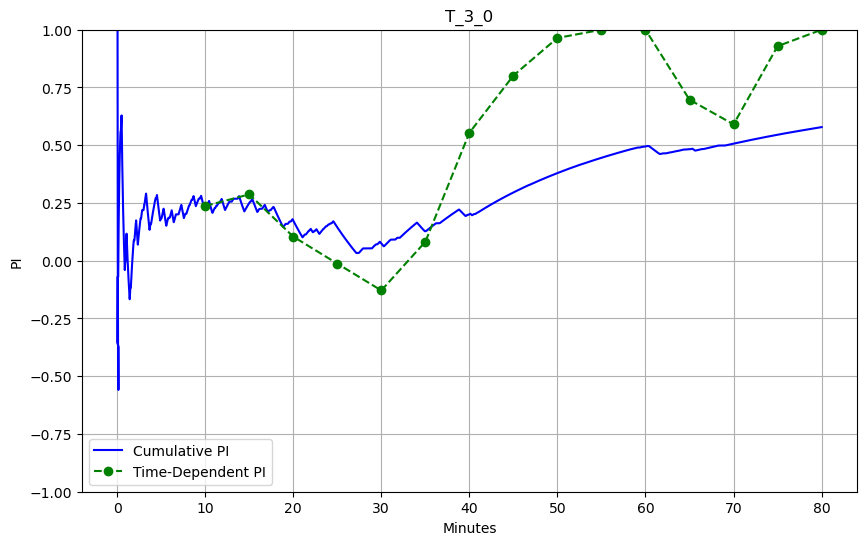

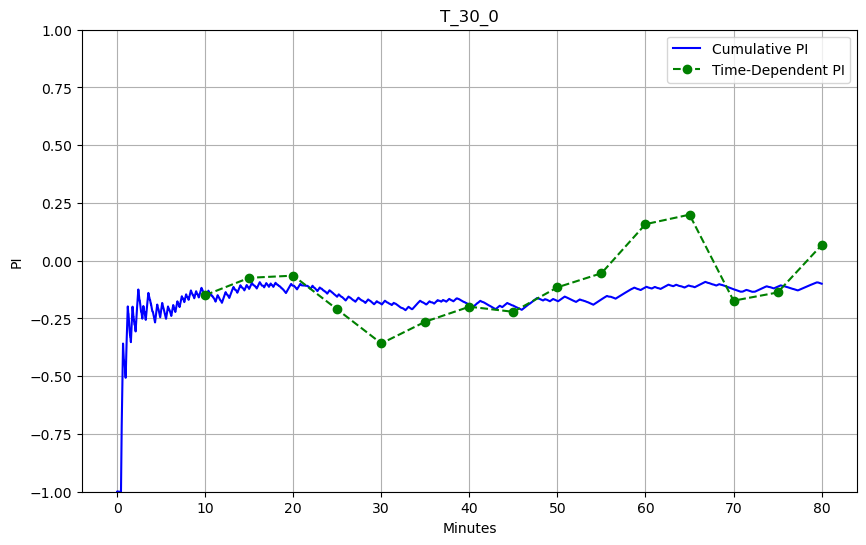

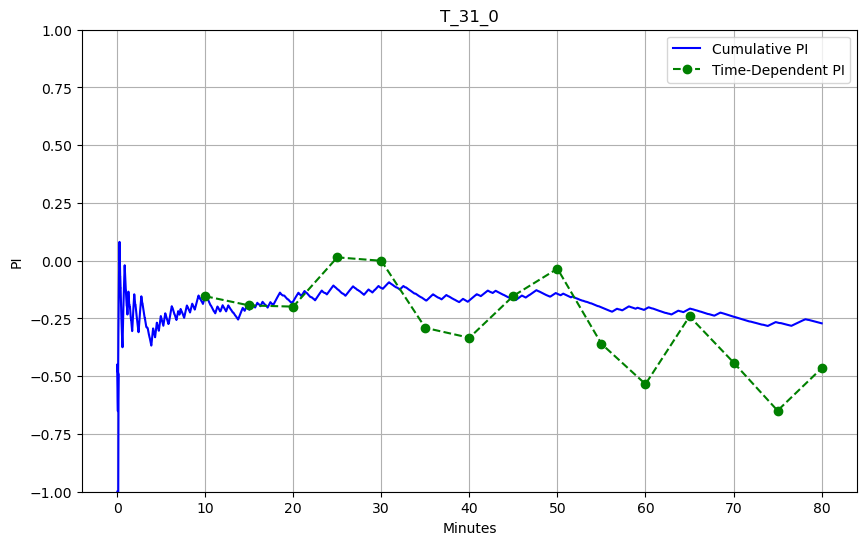

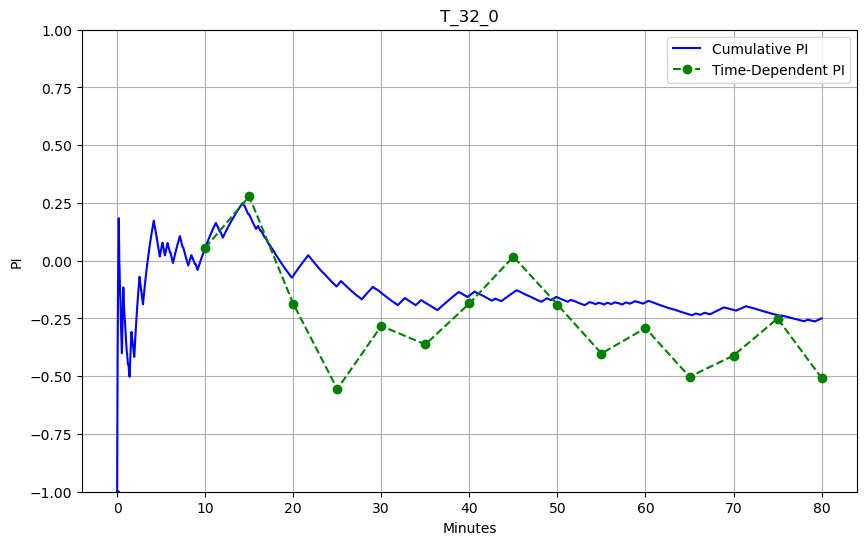

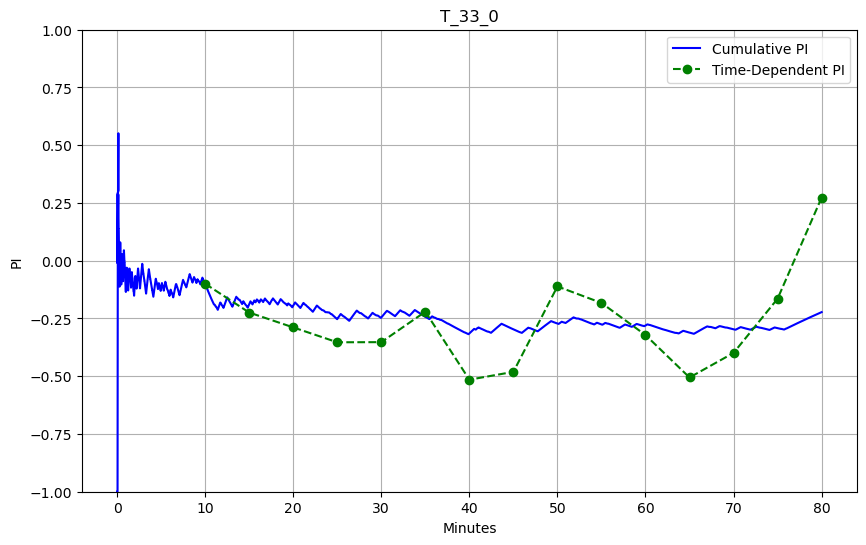

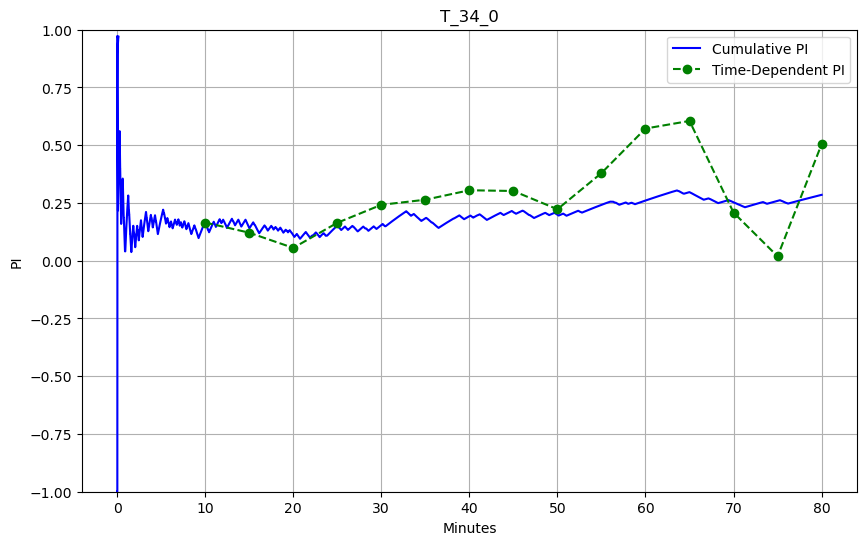

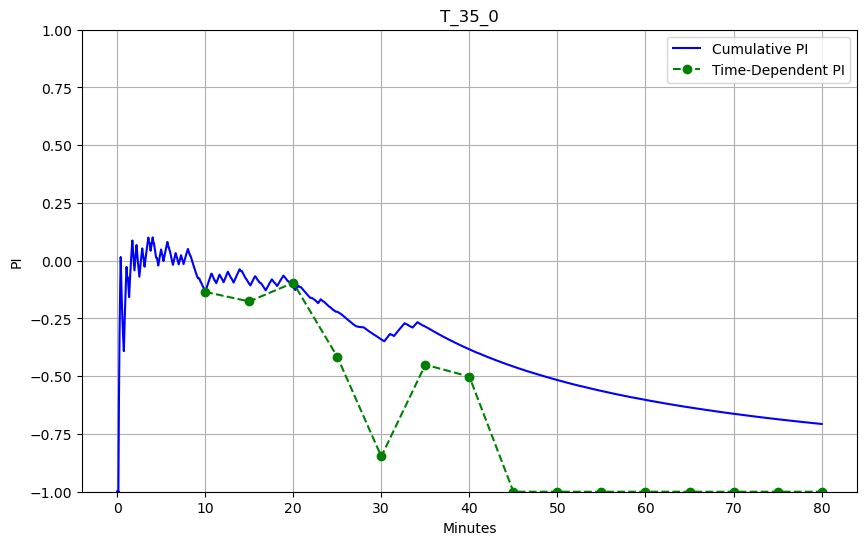

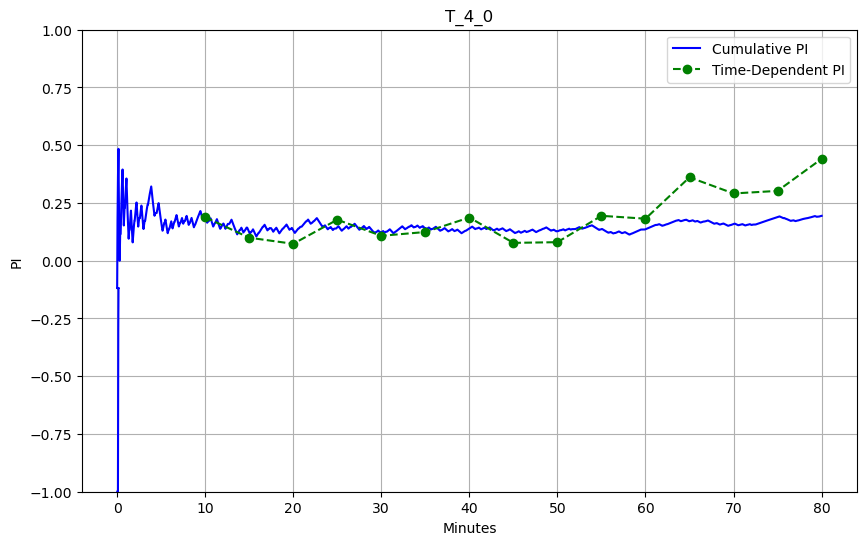

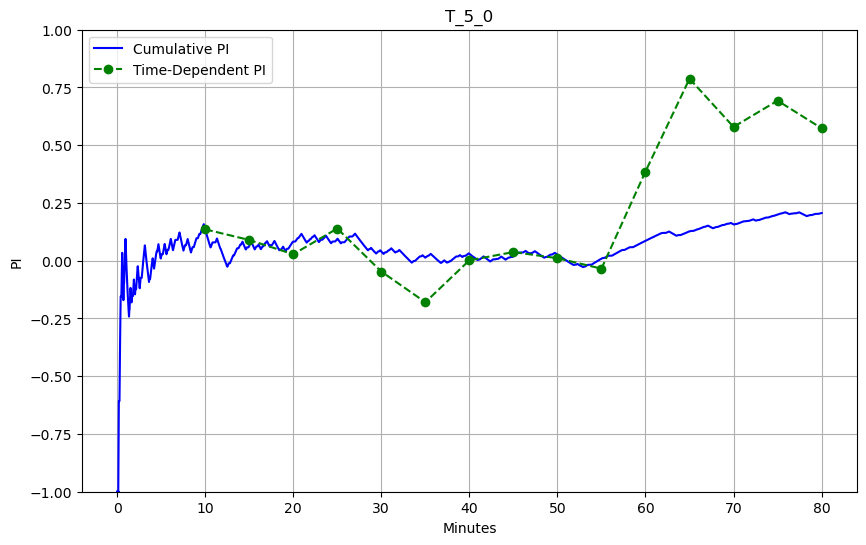

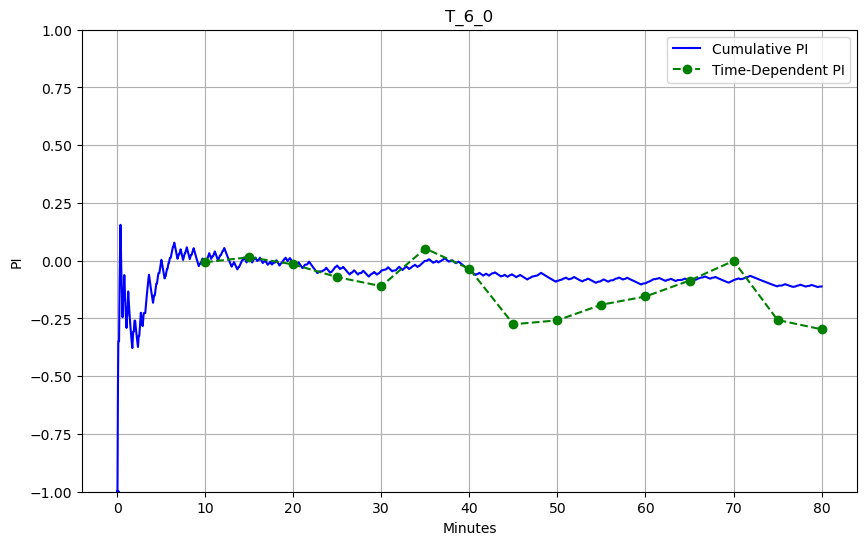

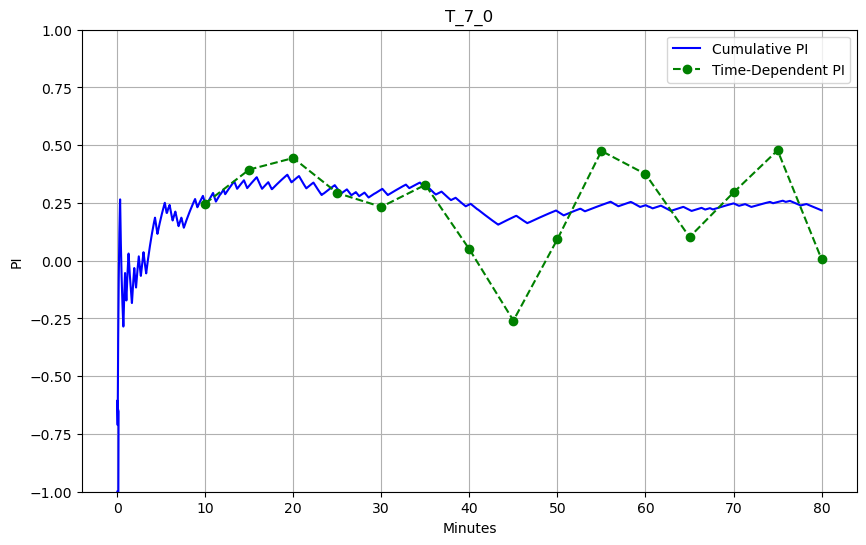

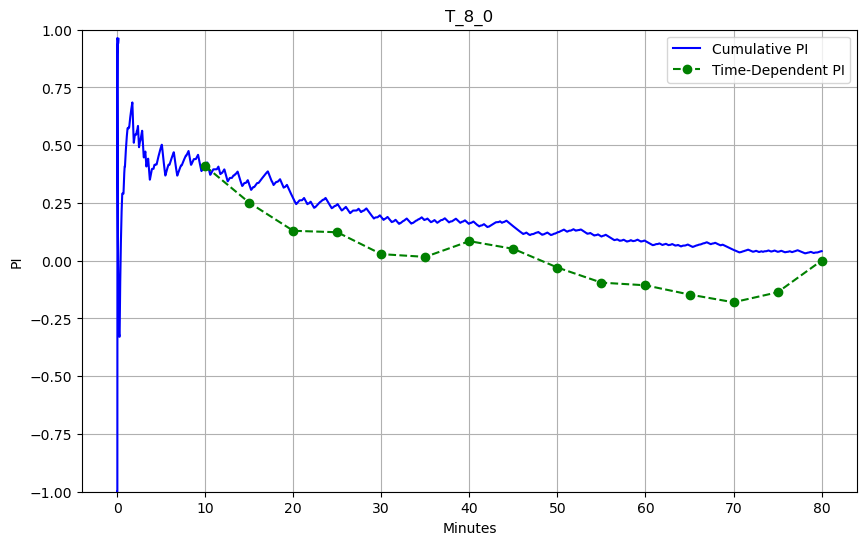

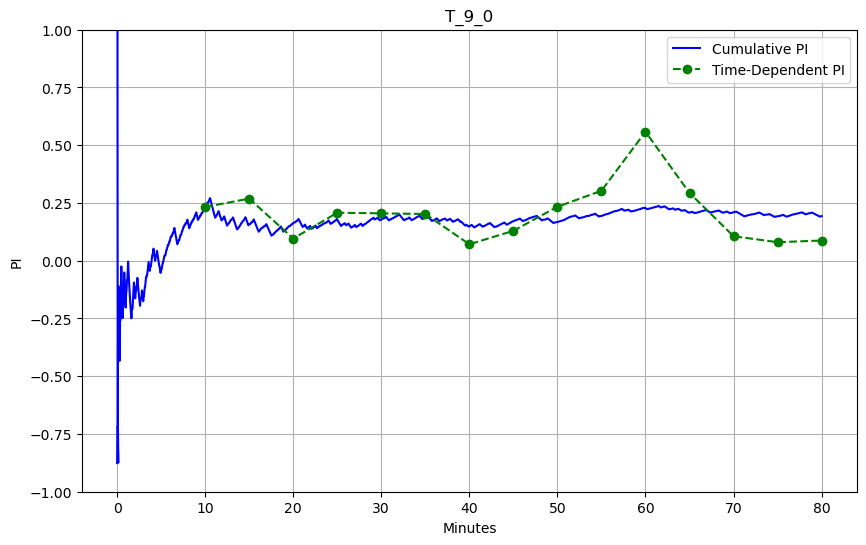

In [12]:
arena.plot_trackers_pis()

**Positional Plots:** Show the X positions of each tracker as a function of time.

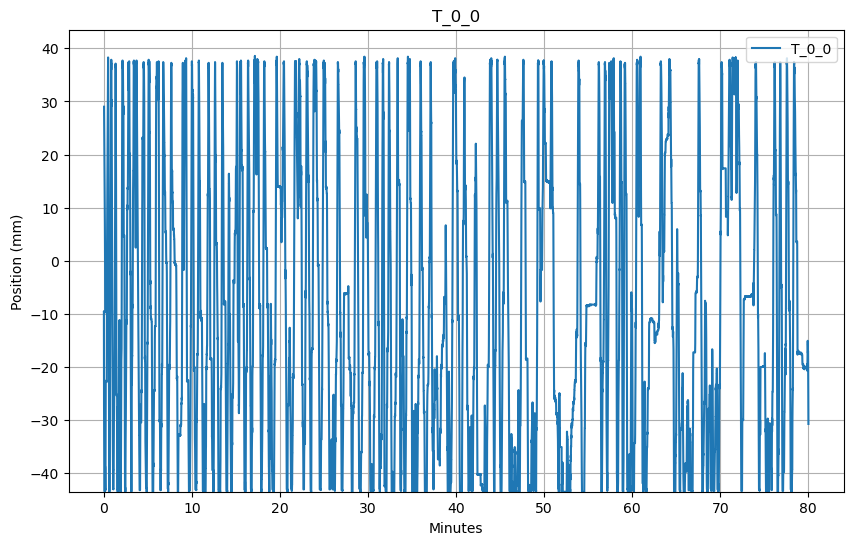

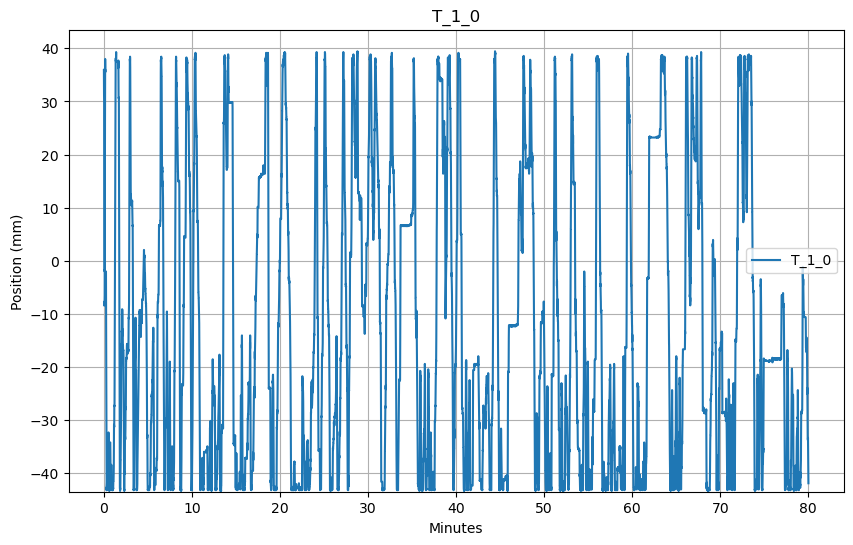

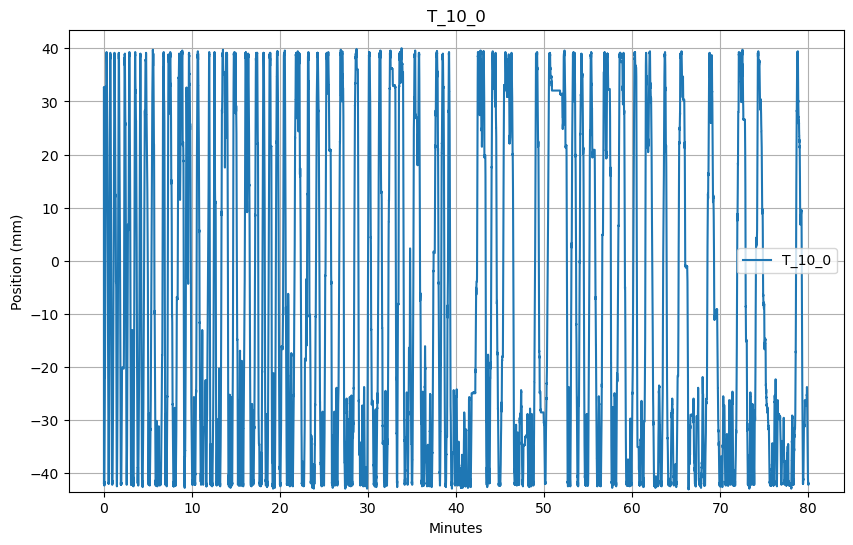

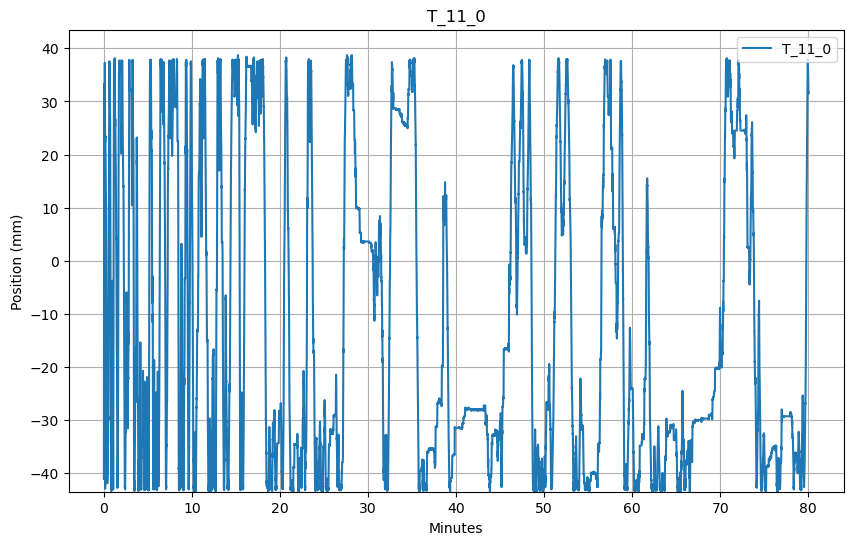

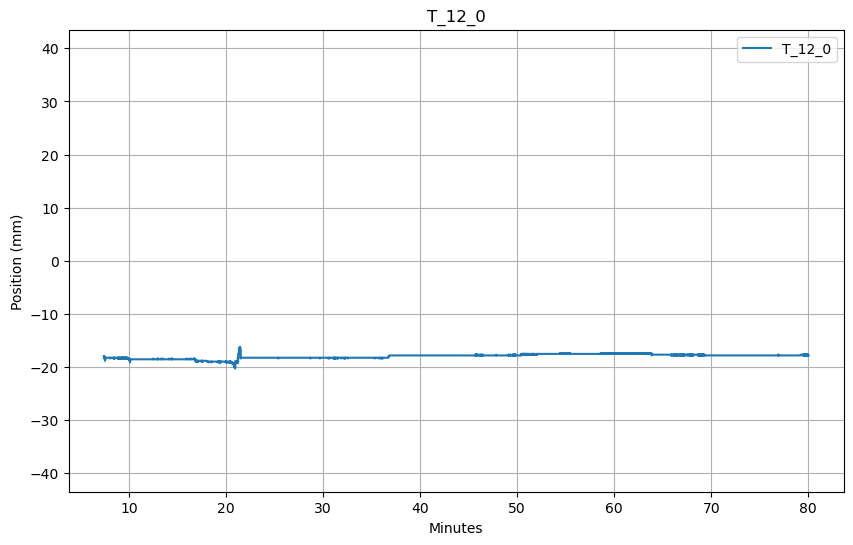

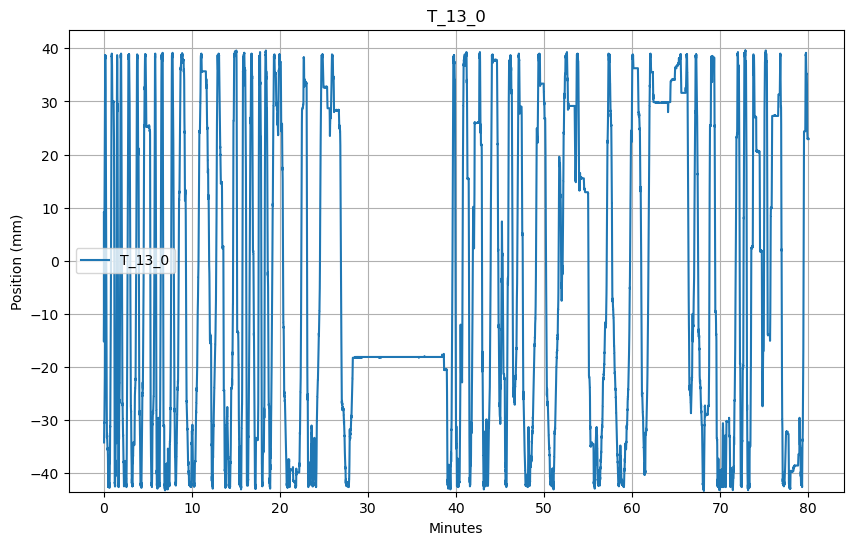

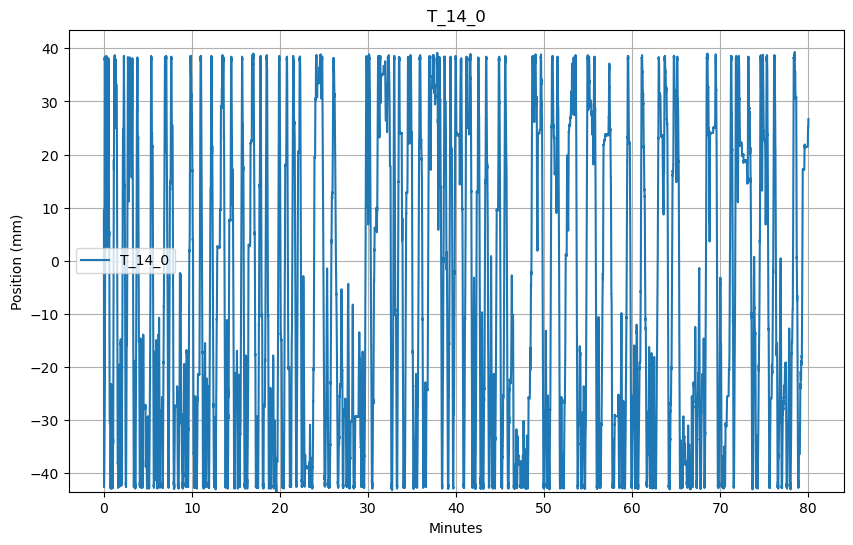

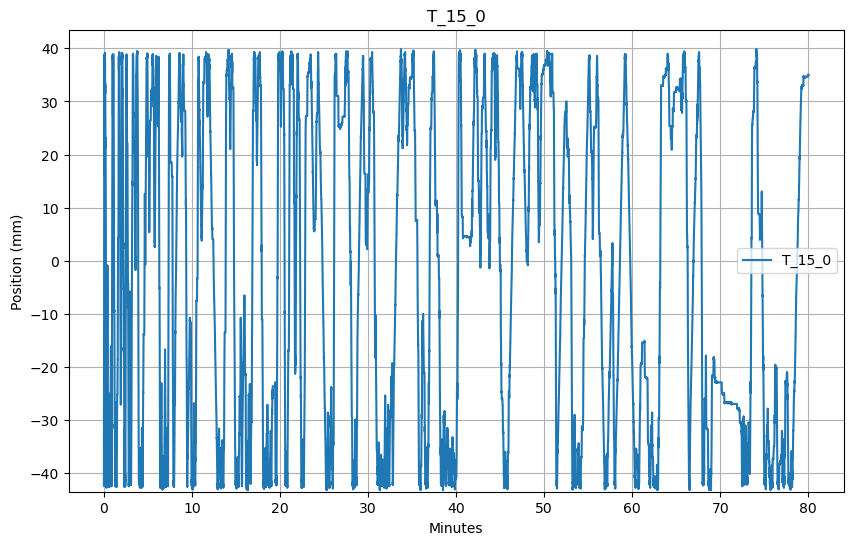

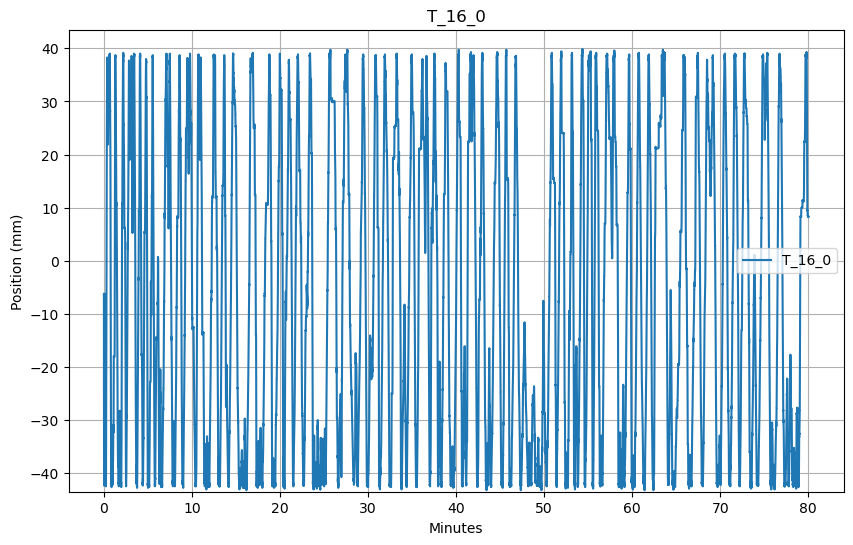

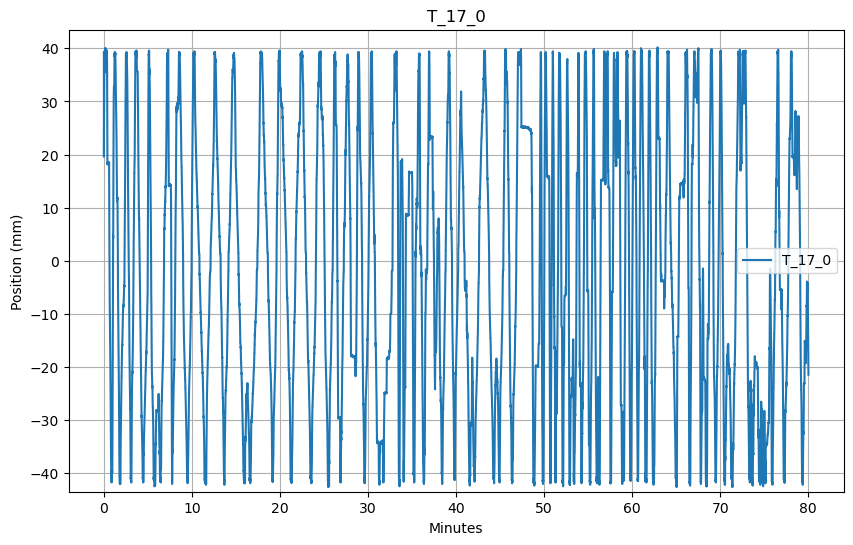

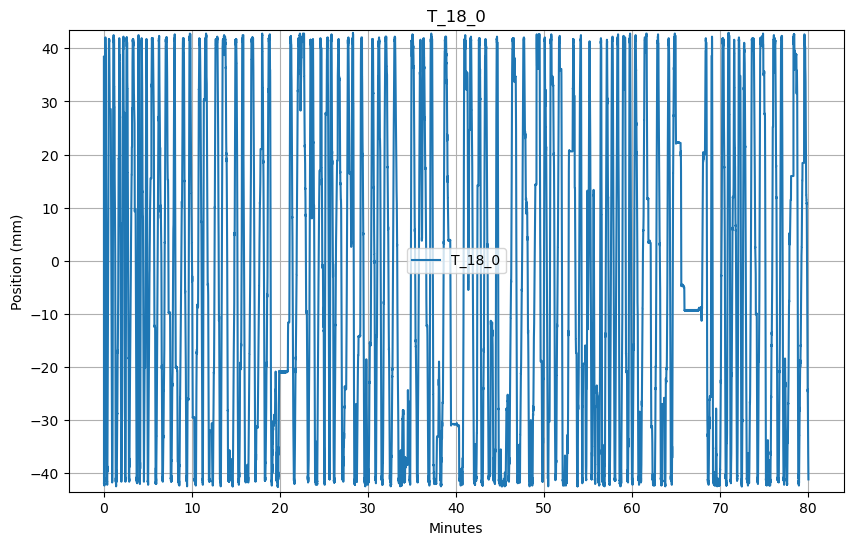

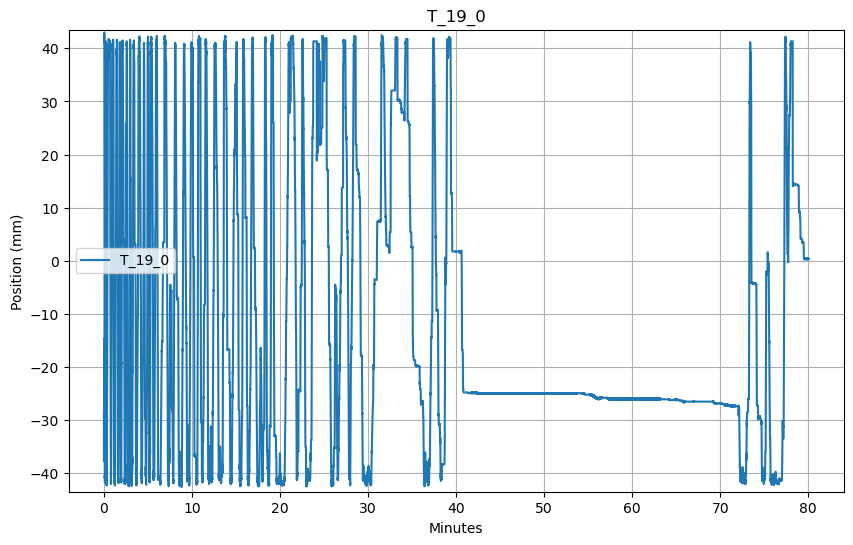

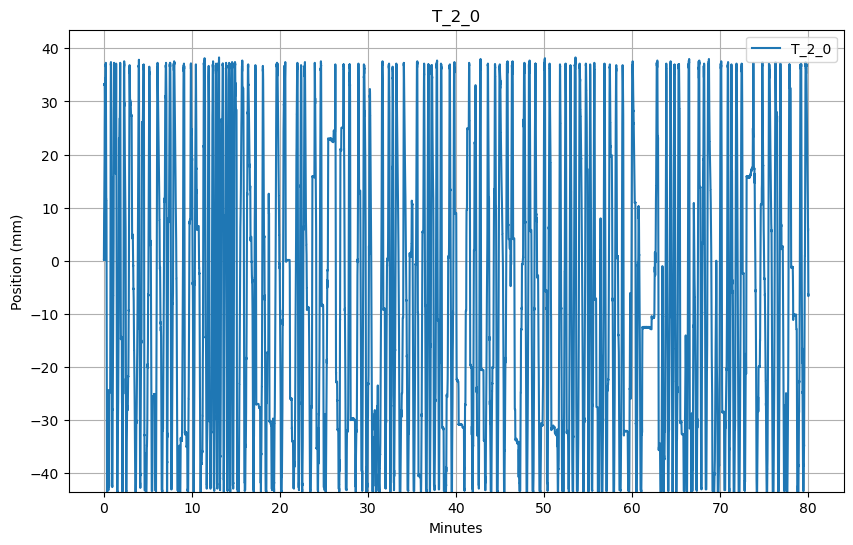

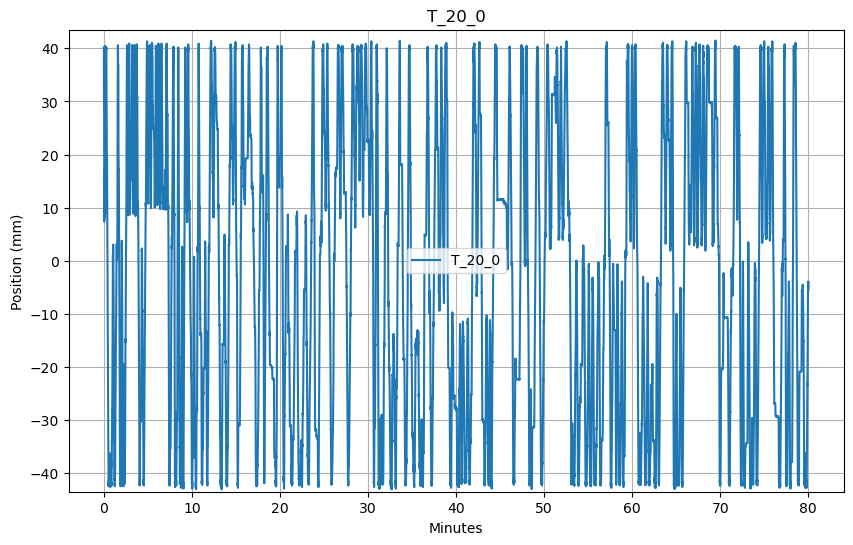

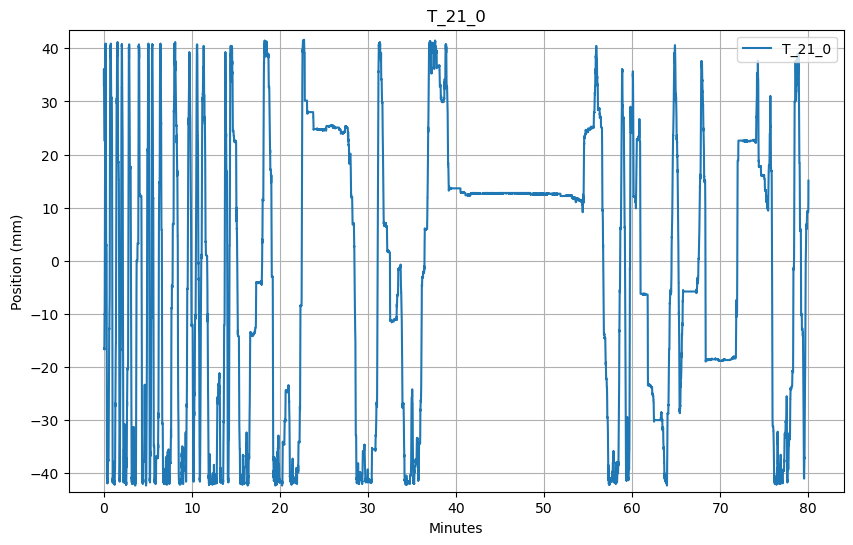

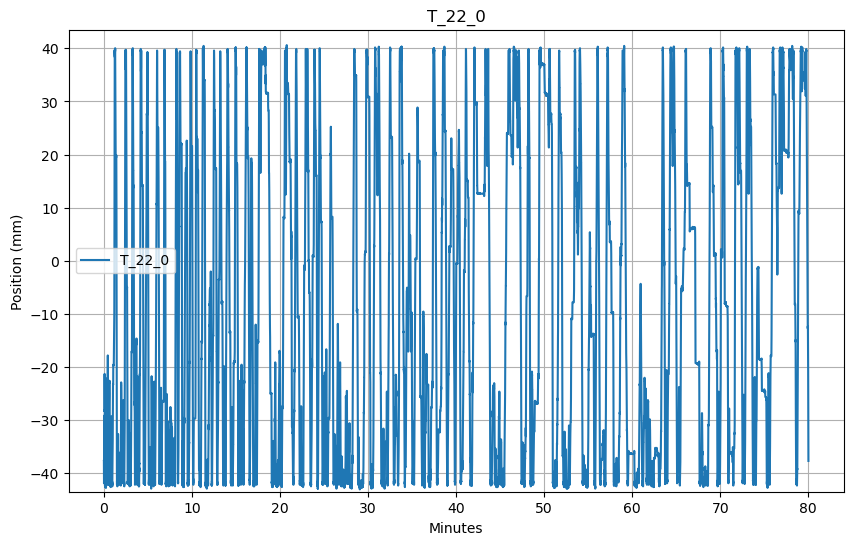

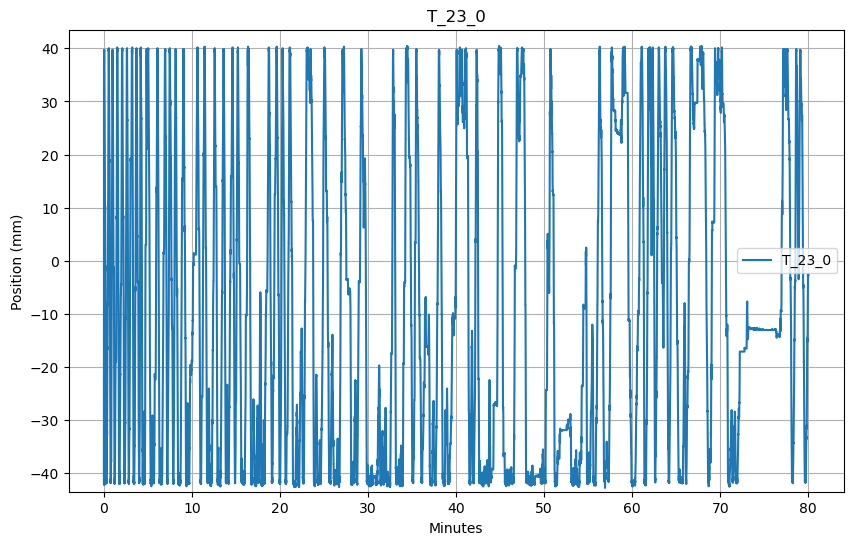

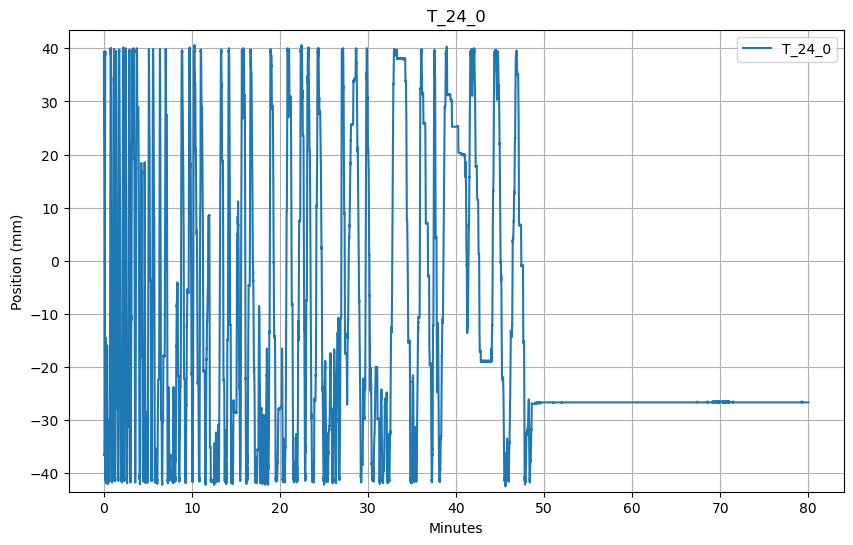

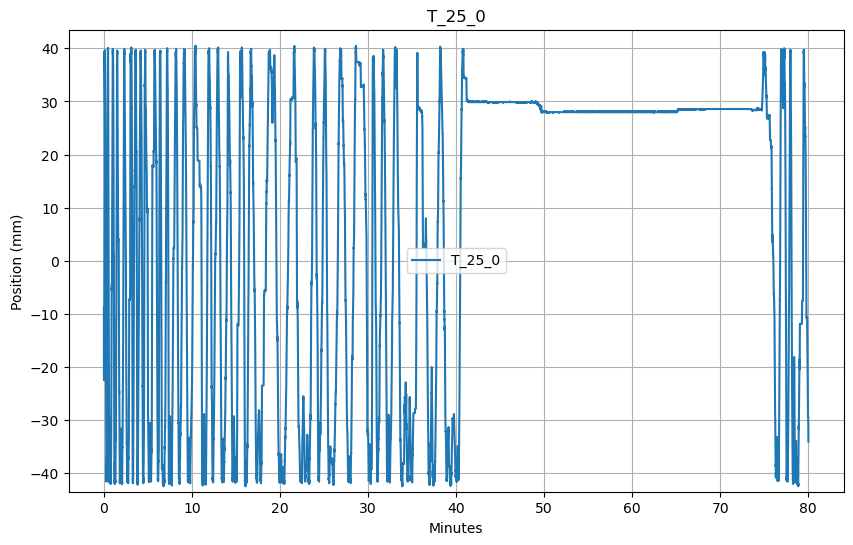

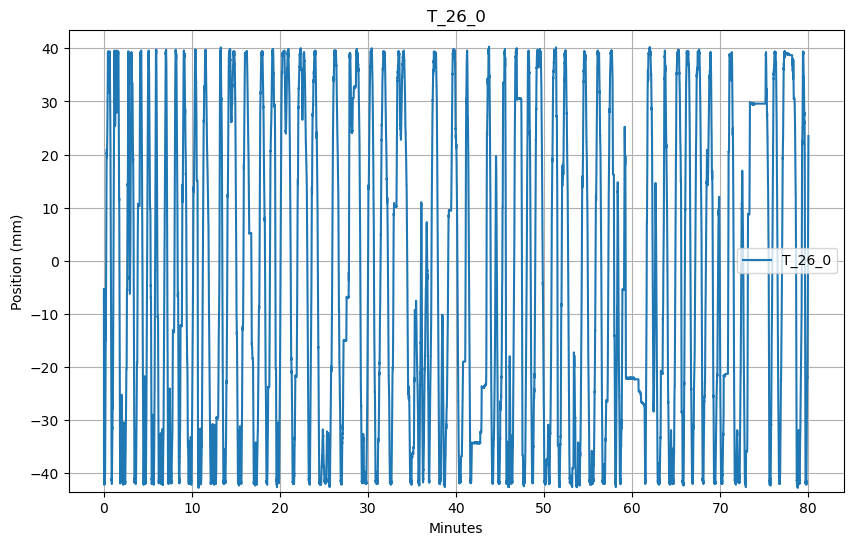

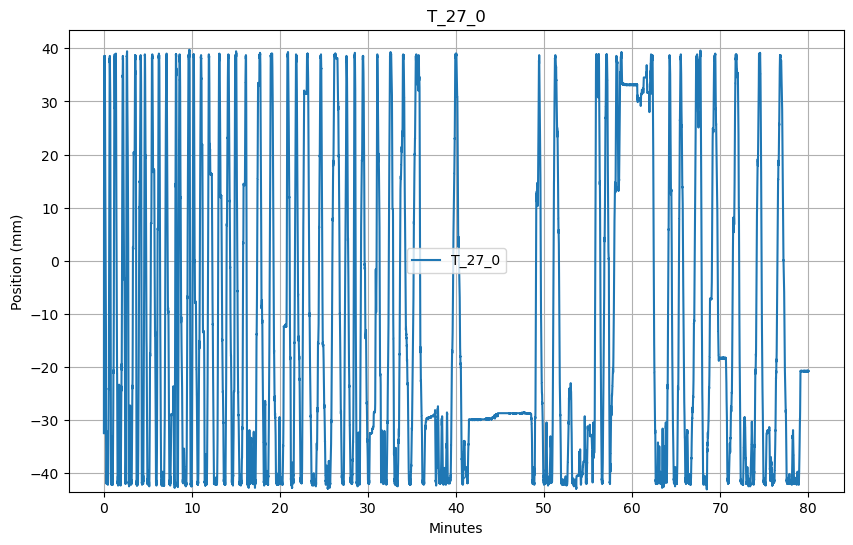

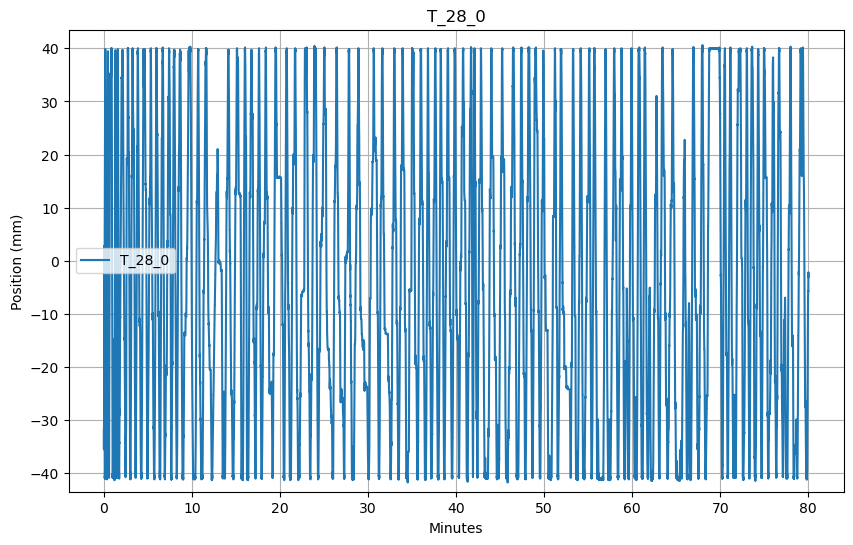

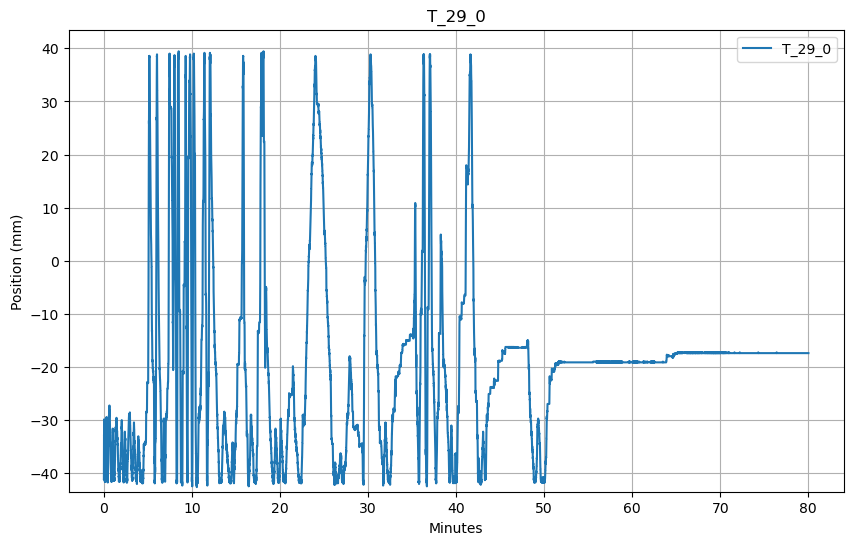

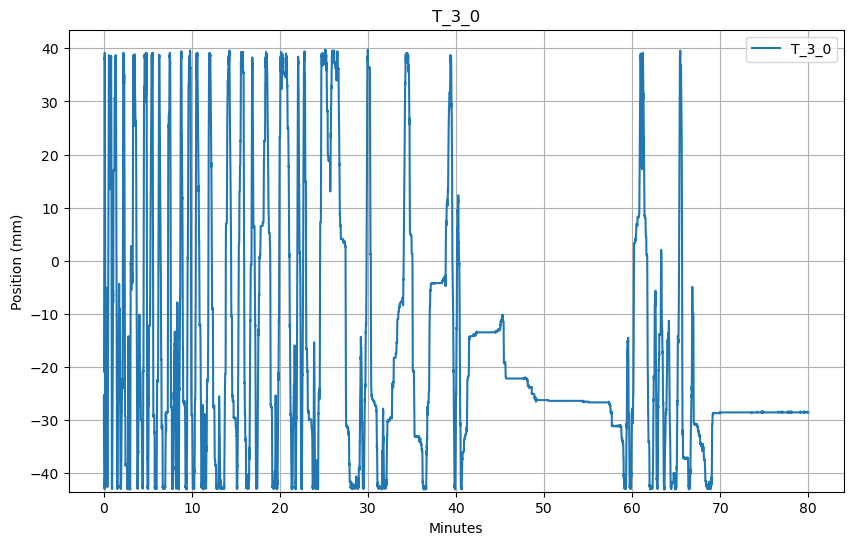

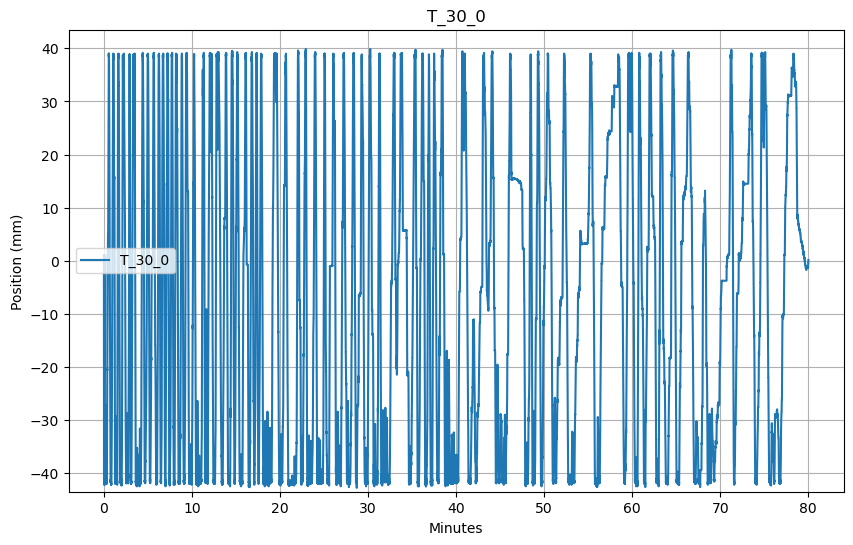

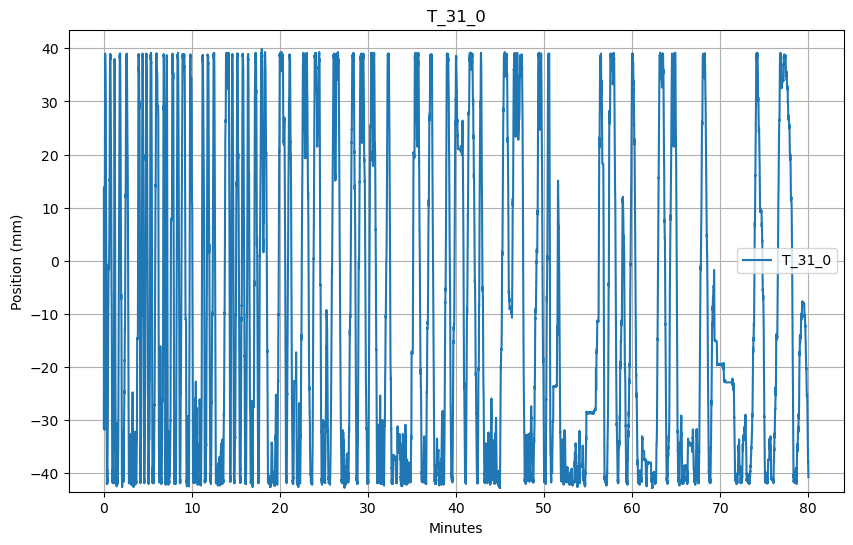

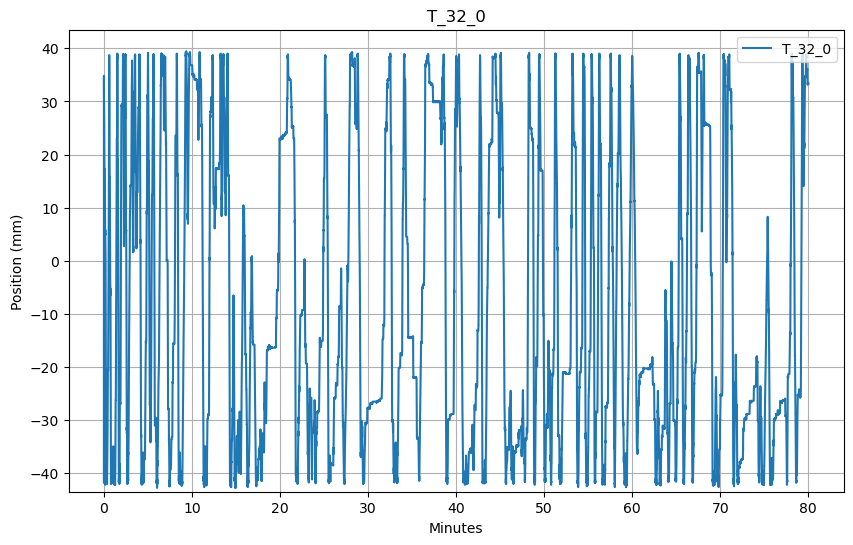

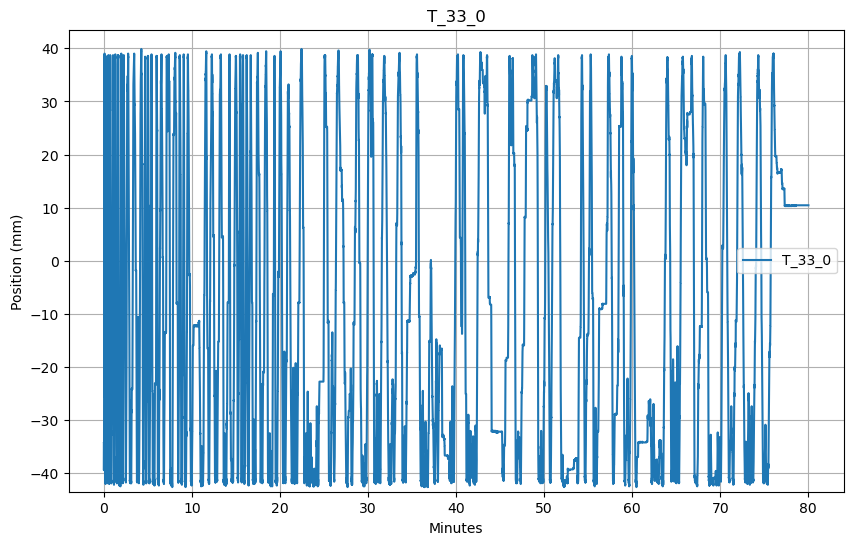

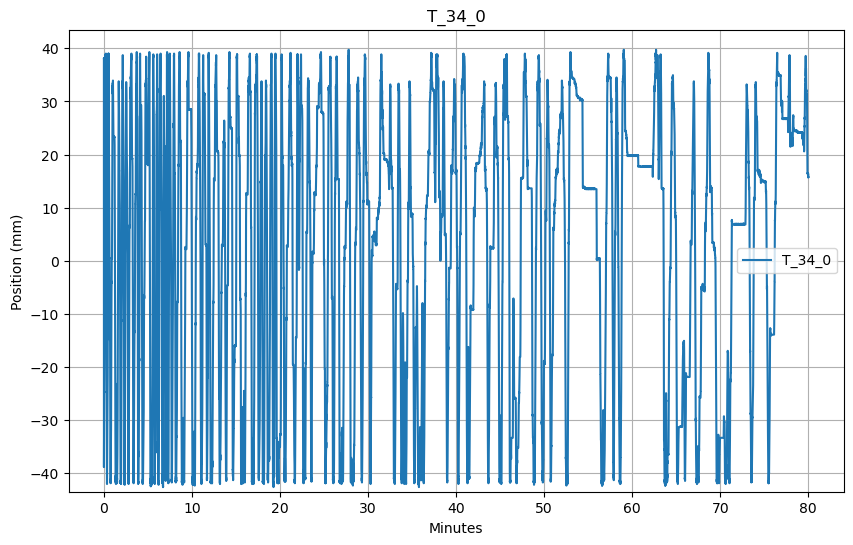

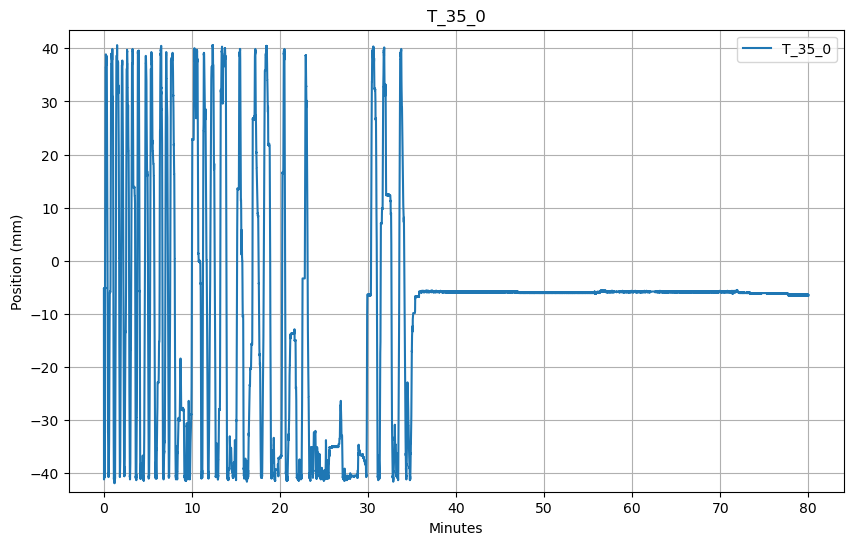

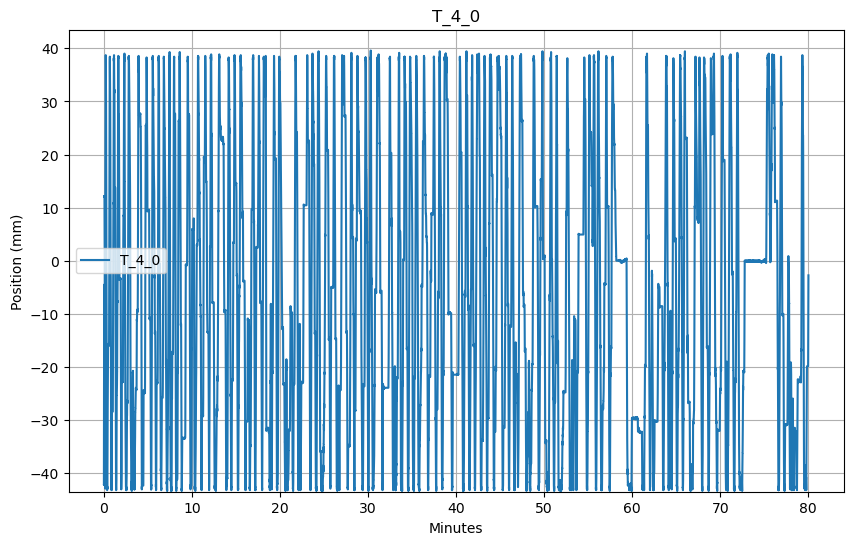

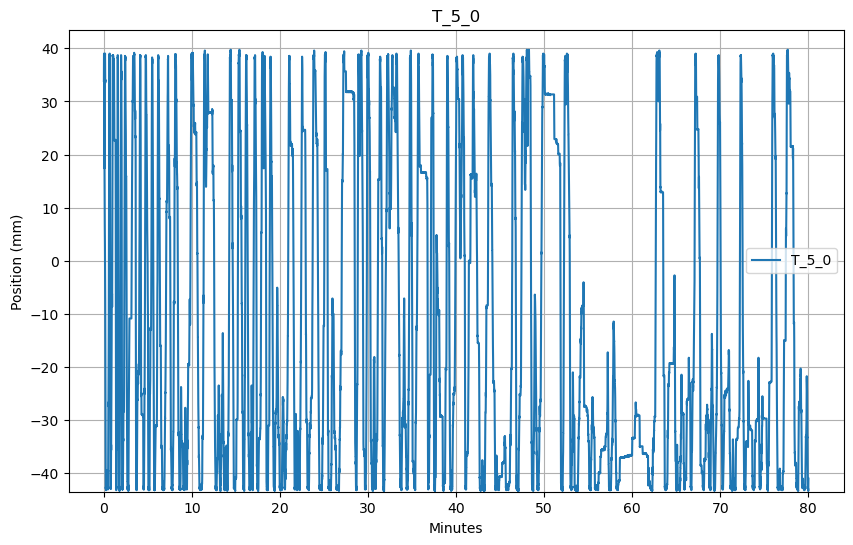

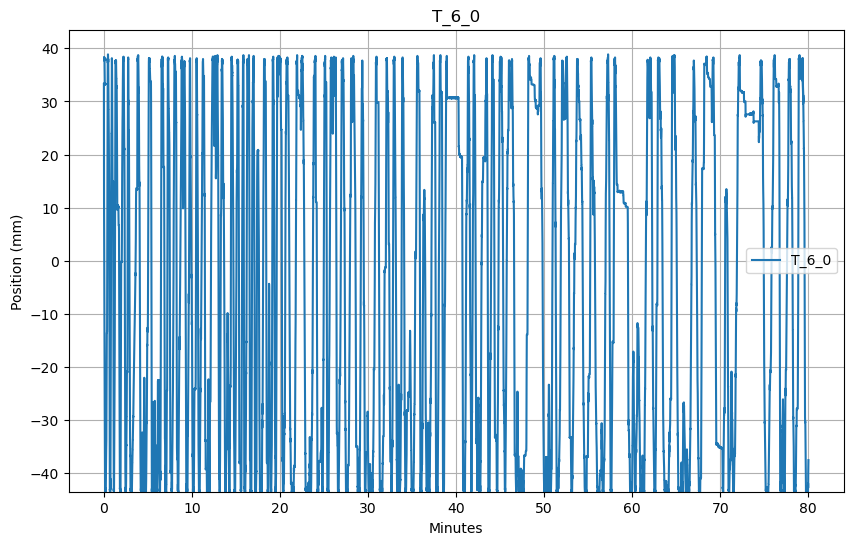

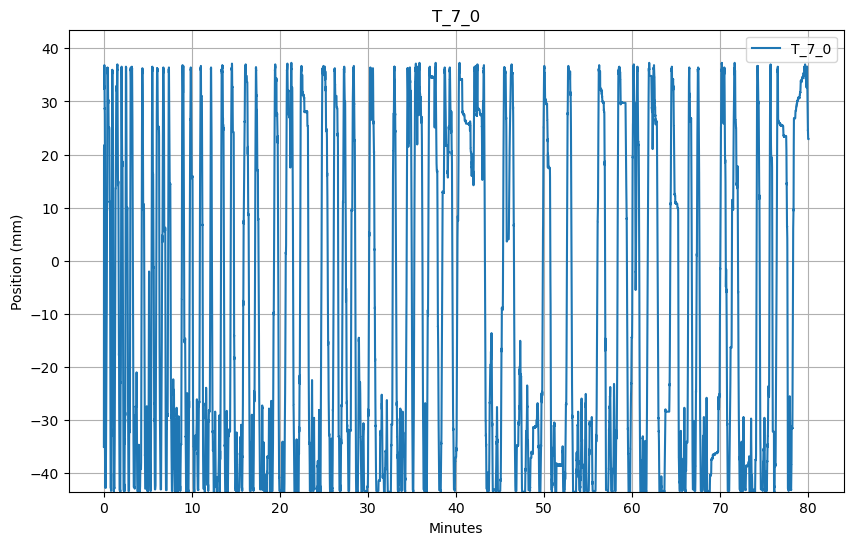

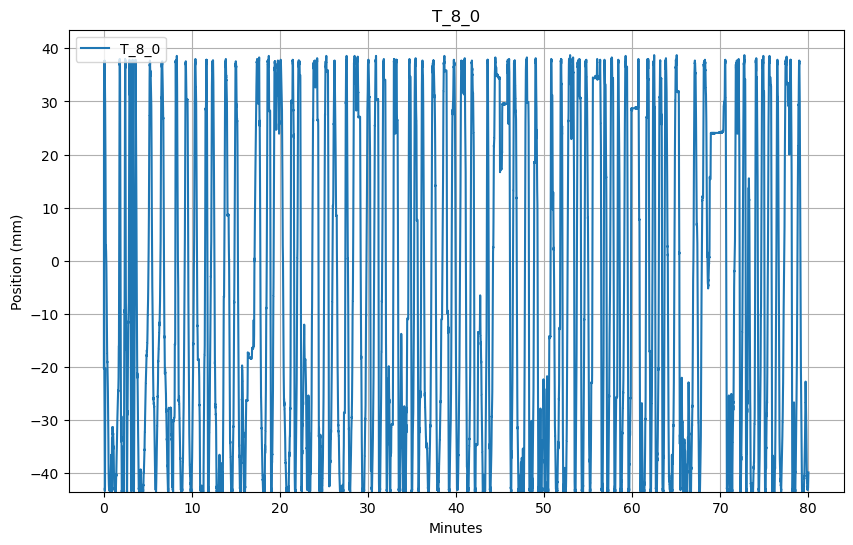

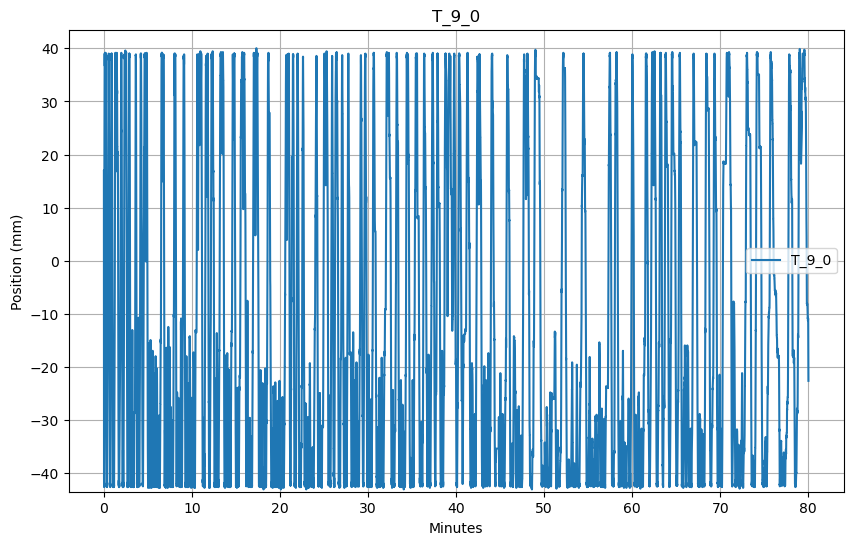

In [13]:
arena.plot_trackers_x()